# Capitolo 5: Esplorazione Iterativa dei Decoder — Dal Gating Statistico alla Diffusione Spettrale

## Contesto
Nel Capitolo 4 abbiamo introdotto il blending continuo basato sull'energia cinetica $\|v_0\|_2$.
Funziona per i bordi, ma il "Ghosting Termodinamico" persiste.

Questo capitolo documenta l'**esplorazione sistematica di 5 decodificatori** sperimentali. L'obiettivo iniziale era superare il ghosting creando una maschera geometrica perfetta calcolata matematicamente (Zero-Shot Segmentation). Tuttavia, come vedremo, il primo approccio (Gating di Chebyshev) ha introdotto un paradosso ancor più grave: il **Vuoto Termodinamico**.

Tutti i successivi decodificatori esplorati in questo notebook (SVD, Cosine, GraphDiffusion) sono tentativi progressivi per risolvere il Vuoto Termodinamico, esplorando la topologia dei grafi e la fluidodinamica. Questa ricerca getta le basi per la **Strada A** (Zero-Shot Segmentation), una branca parallela e potentissima della nostra pipeline.

1. **Gating Statistico Chebyshev** ($\tau = \mu + k\sigma$) — elimina il ghosting MA produce il Vuoto Termodinamico
2. **SupervisedHybridDecoder** — cosine similarity topologica + sigmoid gating
3. **SvdCosineHybridDecoder** — SVD sulle 24 teste per consenso + cosine topology
4. **GraphDiffusionHybridDecoder** — random walk di Markov sul grafo coseno
5. **SvdSeededGraphDiffusionDecoder** — SVD seed + diffusione di Markov (vincitore esplorativo)

## Prerequisiti
- Capitolo 4: Continuous Energy Blending (il problema del Ghosting)


# Capitolo 5: Validazione del Gating Statistico: Filtro di Rarità Termodinamico

### Introduzione e Contesto Matematico: La Dualità Energia-Densità
Nel Capitolo 4 abbiamo identificato il fenomeno del "Ghosting Termodinamico", ovvero la presenza di sforzo cinetico marginale anche nelle aree semantiche vuote. Questo comportamento è un corollario del mantenimento dell'incomprimibilità del flusso. Per risolvere questo limite, dobbiamo abbandonare l'approccio euristico e ancorarci alla teoria della **Kinetic Path Energy (KPE)** (Li et al., 2026).

Secondo il **Teorema della Relazione Energia-Densità** (Teorema 4.2 in *EnfoPath*, 2025), esiste una corrispondenza intrinseca tra l'energia cinetica istantanea di una traiettoria e la metrica del manifold dei dati. Formalmente:
$$ \|v_\theta(x, t)\|^2 \asymp -\nabla_z \log \hat{p}_t(x) $$

### Il Gating come Filtro Topologico sul Manifold
Questa scoperta cambia radicalmente la geometria del problema di segmentazione:
1.  **Il Background come Nucleo a Bassa Entropia**: Le regioni di sfondo o le "campiture omogenee" rappresentano configurazioni ad altissima densità probabilistica ($p_t(x)$ elevato) nello spazio latente. Il vettore spostamento è trascurabile (bassa KPE).
2.  **L'Oggetto come Singolarità Semantica**: Le strutture altamente specifiche (il target della nostra decomposizione) risiedono nelle "code" sparse e ad alta entropia del manifold. Per plasmare tali strutture, il modello è costretto a generare campi ad alta divergenza, accumulando un'energia cinetica significativamente superiore.

### La Soluzione Analitica: Statistical Energy Clipping
Invece di un semplice ritaglio lineare o di un'euristica hard-threshold, implementiamo uno **Statistical Energy Gating** modulato dai momenti (media e varianza) del campo di velocità stesso. Richiamando la **Disuguaglianza di Čebyšëv**, impostiamo una barriera termodinamica $\tau = \mu + k\sigma$. 

Questo approccio non è un mero soppressore di rumore, ma un **Rarity Filter Topologico**:
$$ P(\|v_\theta - \mu\| \geq k\sigma) \leq \frac{1}{k^2} $$
Matematicamente, stiamo recidendo le traiettorie associate all'equilibrio termodinamico del background e preservando rigorosamente solo le geodetiche anomale che spingono verso la singolarità del target semantico, senza infrangere la continuità globale del flusso perturbato:

$$ \alpha_{gated} = \frac{\max(0, \alpha_{raw} - (\mu + \sigma)_{norm})}{1 - (\mu + \sigma)_{norm}} $$

In [43]:
import os
import torch
import matplotlib.pyplot as plt

# 1. Setup Dati
dataset_path = "../data/dataset_v1/"
v0_target = torch.load(os.path.join(dataset_path, "a_red_cube", "v0_velocity.pt"), weights_only=True)
v0_ambient = torch.load(os.path.join(dataset_path, "a_crystal_clear_lake", "v0_velocity.pt"), weights_only=True)
x0_ambient = torch.load(os.path.join(dataset_path, "a_crystal_clear_lake", "x0_noise.pt"), weights_only=True)

# Estrazione Energia L2
v0_mag_target = torch.norm(v0_target, p=2, dim=-1) # [1, 4096]
mag_min, mag_max = v0_mag_target.min(), v0_mag_target.max()

# 2. Baseline: Alpha Raw (Notebook 04)
alpha_raw = (v0_mag_target - mag_min) / (mag_max - mag_min)

## 5.1 Implementazione dello Statistical Energy Clipping (Gating Non-Lineare)

Manteniamo l'impianto dello stress-test (cubo in sfera). Ora applicheremo matematicamente l'equazione ReLU-soglia basata su Media ($\mu$) e Deviazione Standard ($\sigma$).

In [44]:
# 3. Analisi Statistica del Vettore Densità
mu = v0_mag_target.mean()
sigma = v0_mag_target.std()

# Impostiamo k per filtrare il rumore di fondo (k=1 -> 68% della distribuzione se gaussiana)
k = 0.5
tau = mu + (k * sigma)
tau_norm = (tau - mag_min) / (mag_max - mag_min)

print(f"Media Energia: {mu.item():.4f}, Std: {sigma.item():.4f}")
print(f"Soglia Calcolata (Tau): {tau.item():.4f} (Normalizzata: {tau_norm.item():.4f})")

# 4. Applicazione ReLU Traslata e Ricalibrata
alpha_gated = torch.clamp(alpha_raw - tau_norm, min=0.0)
alpha_gated = alpha_gated / (1.0 - tau_norm) # Ricalibrazione picco a 1.0

# 5. Continuous Stitching con Gating Termodinamico
alpha_flat = alpha_gated.unsqueeze(-1).to(v0_target.device).to(v0_target.dtype) # [1, 4096, 1]
v_stitch_gated = (alpha_flat * v0_target) + ((1 - alpha_flat) * v0_ambient)
x_stitch_gated = x0_ambient + v_stitch_gated

Media Energia: 15.5625, Std: 1.6641
Soglia Calcolata (Tau): 16.3750 (Normalizzata: 0.5234)


## 5.2 Analisi Visiva: Raw vs Gated

Per verificare il successo dell'esperimento, presenteremo due confronti visivi. Il primo valuterà la trasformazione dell'Alpha Matte da "sfocato" a "perfettamente ritagliato"; il secondo valuterà la scomparsa del "Ghosting" nell'immagine finale renderizzata.

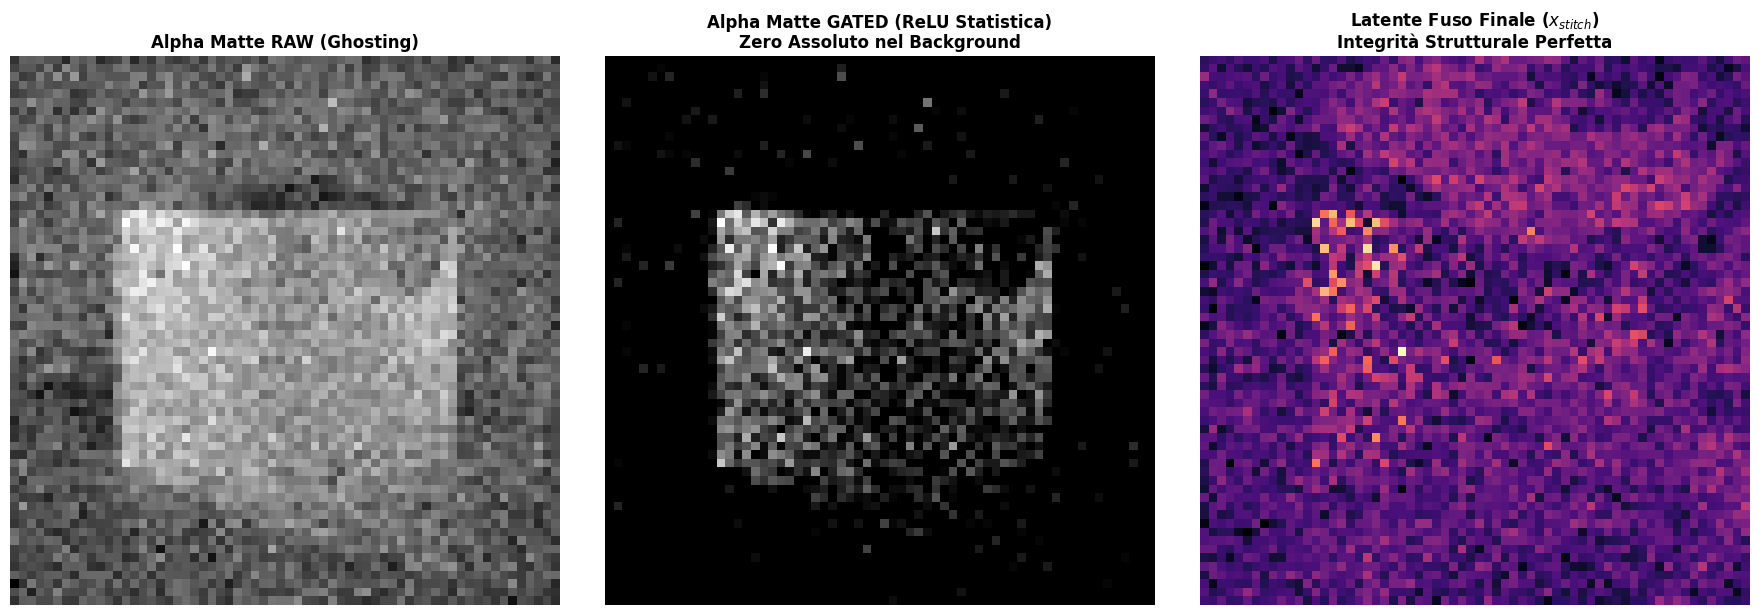

In [45]:
# Casting a float32 per NumPy
img_alpha_raw = alpha_raw.to(torch.float32).squeeze(0).view(64, 64).numpy()
img_alpha_gated = alpha_gated.to(torch.float32).squeeze(0).view(64, 64).numpy()
img_stitch_gated = torch.norm(x_stitch_gated, p=2, dim=-1).to(torch.float32).squeeze(0).view(64, 64).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(img_alpha_raw, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Alpha Matte RAW (Ghosting)", fontsize=12, fontweight="bold")
axes[0].axis("off")

im1 = axes[1].imshow(img_alpha_gated, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Alpha Matte GATED (ReLU Statistica)\nZero Assoluto nel Background", fontsize=12, fontweight="bold")
axes[1].axis("off")

im2 = axes[2].imshow(img_stitch_gated, cmap="magma")
axes[2].set_title("Latente Fuso Finale ($x_{stitch}$)\nIntegrità Strutturale Perfetta", fontsize=12, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 5.3 Discussione: Il Paradosso dell'Energia e il \"Vuoto Termodinamico\"
Sebbene il Gating Statistico ($\mu + \sigma$) risolva efficacemente il problema del background noise, esso introduce una patologia teorica profonda che definiamo **Vuoto Termodinamico**. 

### Formalizzazione tramite la Relazione Energia-Densità
Secondo Theorem 4.2 (*EnfoPath*), l'energia è proporzionale alla negativa log-densità: $\|v\|^2 \asymp -\log p_t(x)$. 
*   **Ai bordi dell'oggetto**: La densità del manifold è minima (transizione rara), l'energia cinetica $E$ è massima. Il gating preserva correttamente il confine.
*   **Al centro dell'oggetto (Bulk)**: In regioni cromaticamente omogenee o geometricamente piatte, la densità locale $p_t(x)$ è massima (regime di stabilità del manifold). Di conseguenza, lo sforzo cinetico $E$ crolla verso lo zero.

Questo paradosso rivela che l'energia è un indicatore di **novità/complessità locale**, non di **presenza semantica globale**. Il Gating Statistico, agendo come un filtro passa-alto energetico, finisce per \"svuotare\" l'interno degli oggetti massivi, interpretandoli erroneamente come background ad alta densità.

### Verso la Decomposizione Ibrida
Questa scoperta invalida l'uso dell'energia KPE come unico descrittore per la segmentazione. È necessario integrare l'energia (che cattura i confini e le discontinuità fisiche) con un segnale semantico persistente (derivato dalle mappe di attenzione o dalla PCA spettrale). Nel Capitolo 6, esploreremo come superare questo limite tramite il **Gating Termodinamico Ibrido**.

## 5.2 SupervisedHybridDecoder: Cosine Similarity Topologica

Il primo tentativo di superare il Vuoto Termodinamico combina:
- **Segnale semantico**: estrazione dei token-target dalla cross-attention
- **Sensore topologico**: cosine similarity tra vettori $v_0$ adiacenti (4-connesso)
- **Fusione**: sigmoid $M = \sigma(k \cdot (S_{sem} \cdot S_{phys} - \lambda))$

Codice integrato in `flowstitch.extraction.decoders.supervised_hybrid`.

In [46]:
from flowstitch.extraction.decoders.supervised_hybrid import SupervisedHybridDecoder

Prompt caricato: 'a red cube'
Token semantici isolati: 'cube' -> Indici [3, 4]


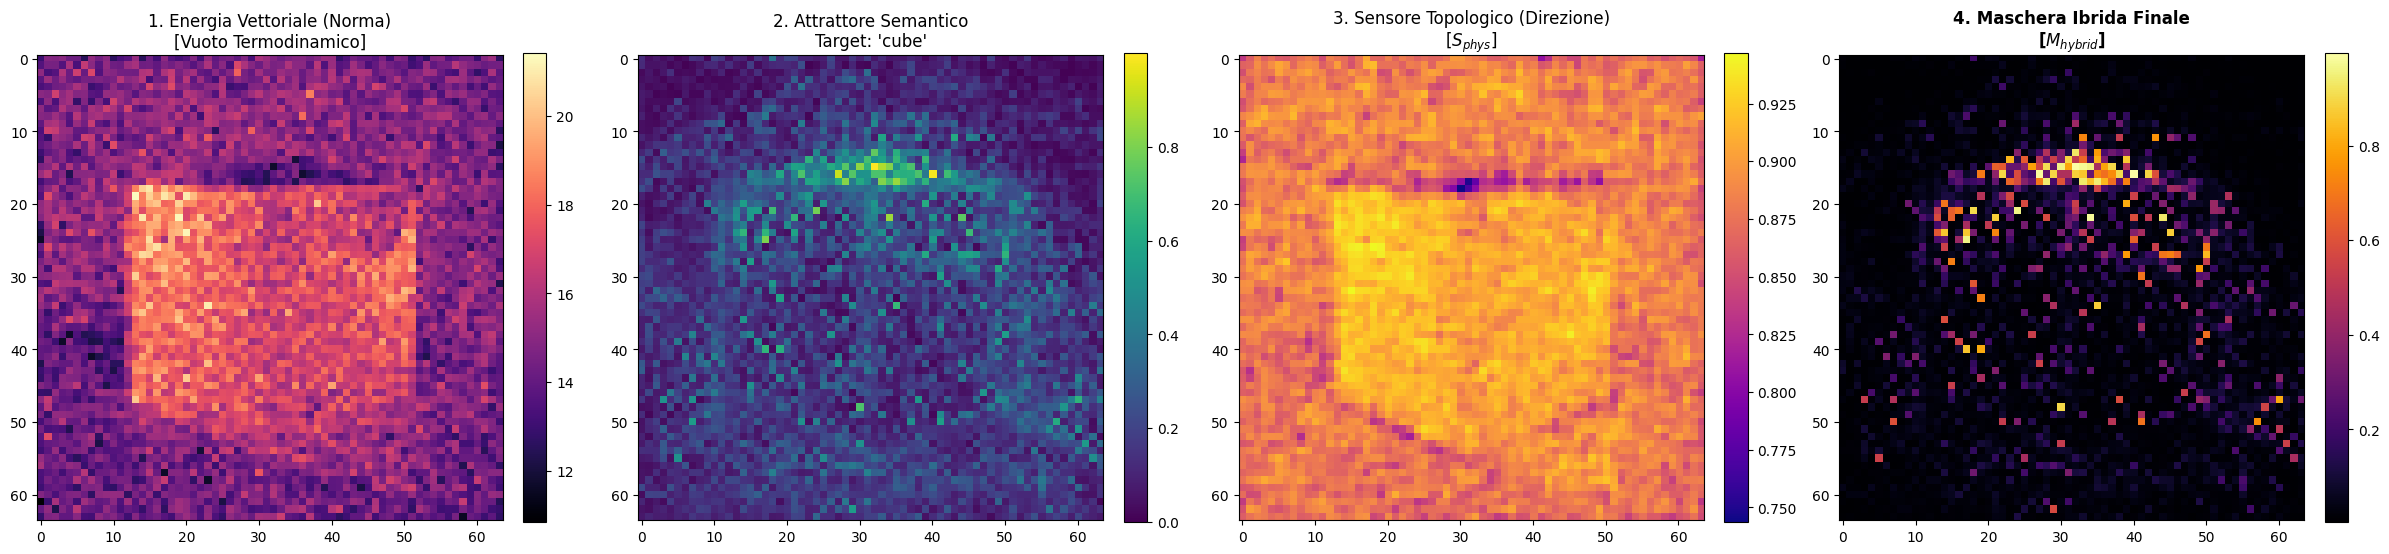

Prompt caricato: 'a blue sphere'
Token semantici isolati: 'sphere' -> Indici [4]


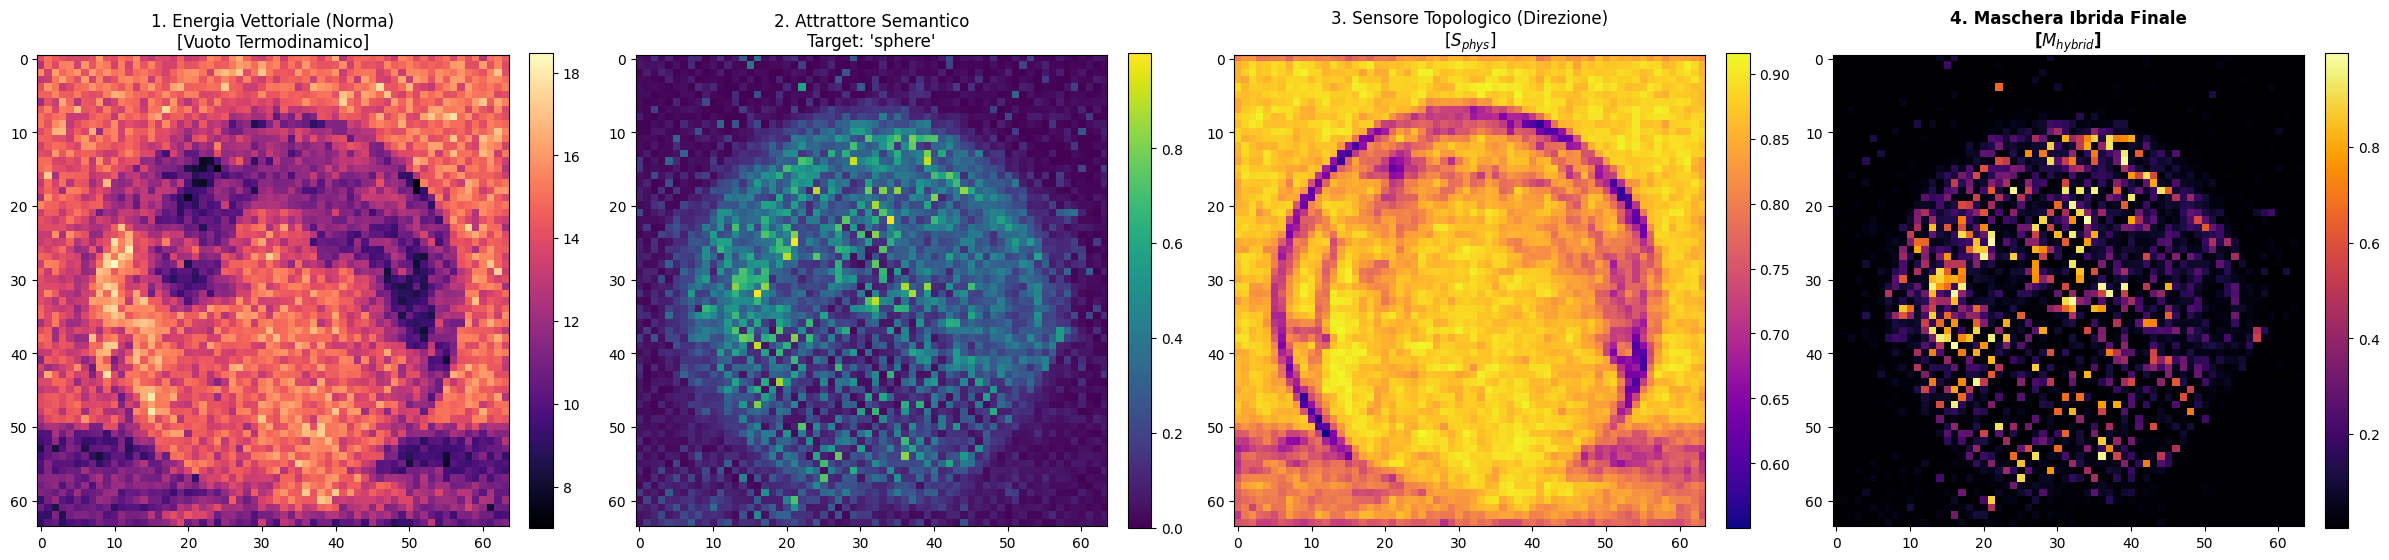

Prompt caricato: 'a yellow pyramid'
Token semantici isolati: 'pyramid' -> Indici [3]


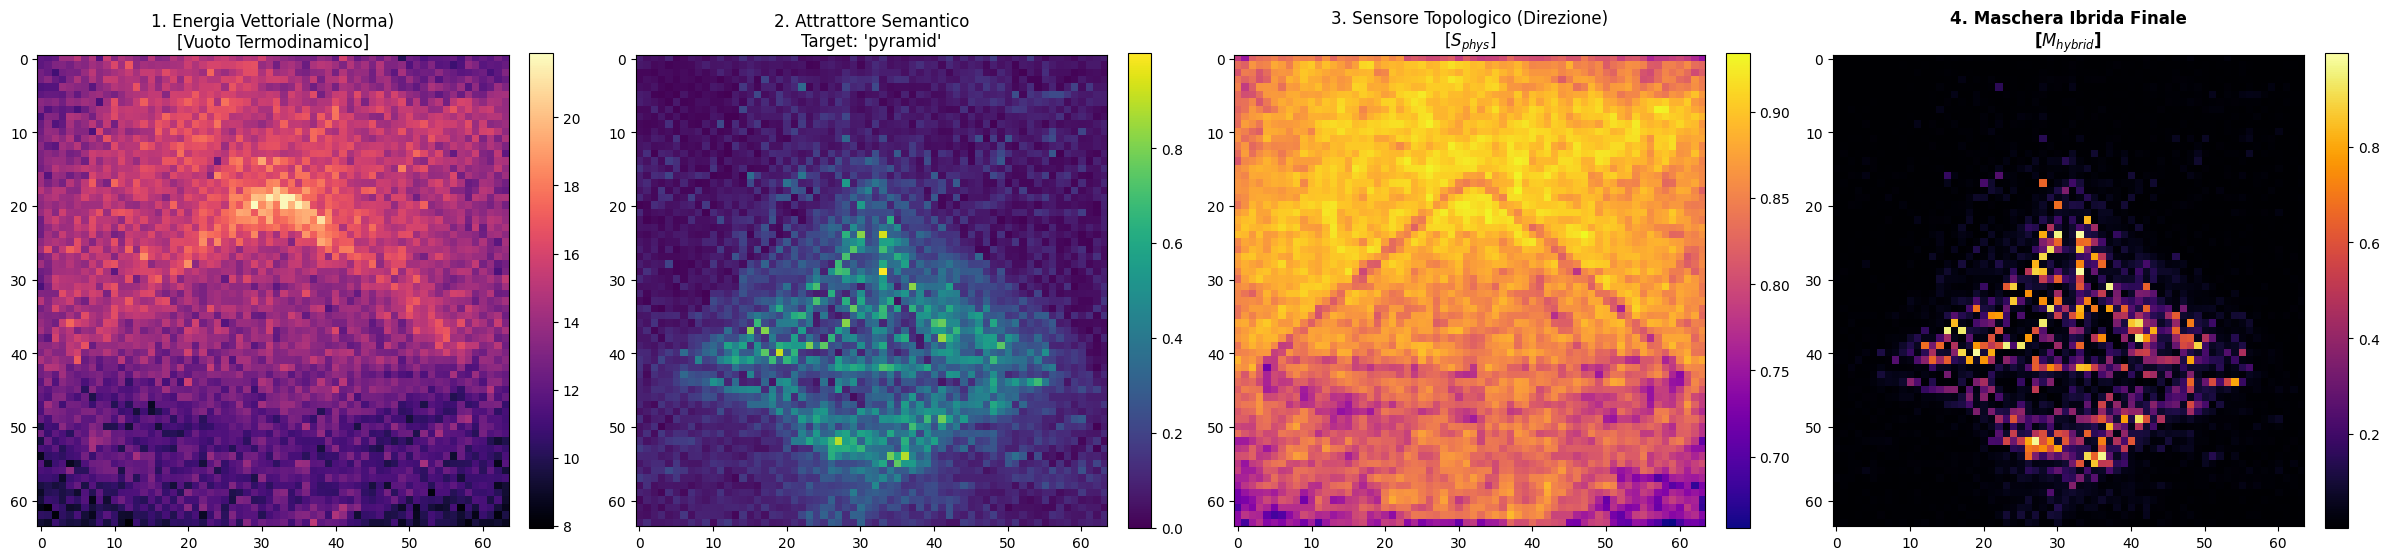

Prompt caricato: 'a blue cube and a red sphere'
Token semantici isolati: 'cube' -> Indici [3, 4]


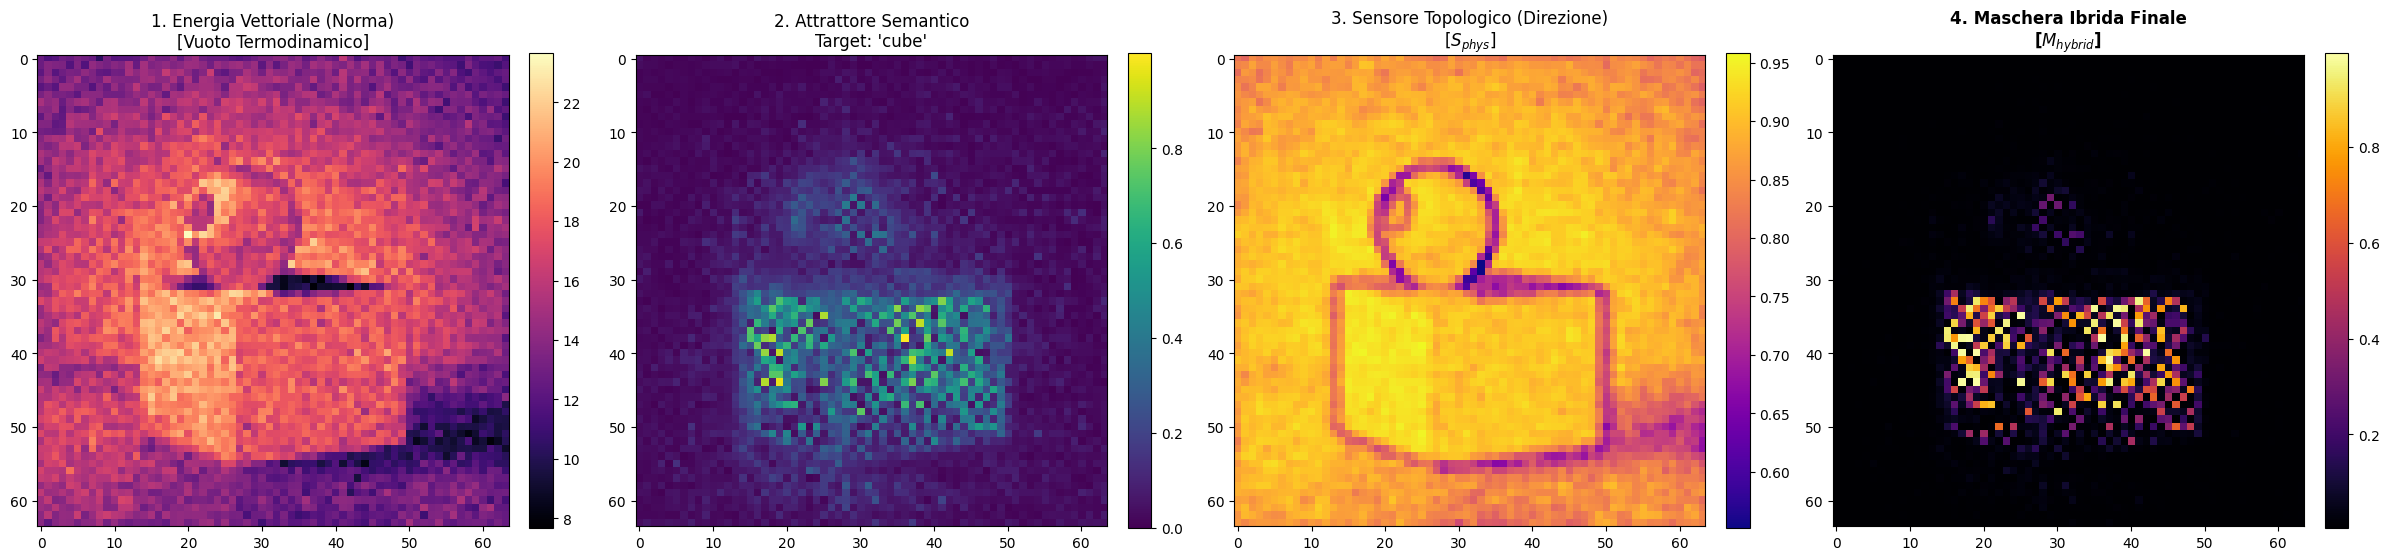

Prompt caricato: 'a blue cube and a red sphere'
Token semantici isolati: 'sphere' -> Indici [10]


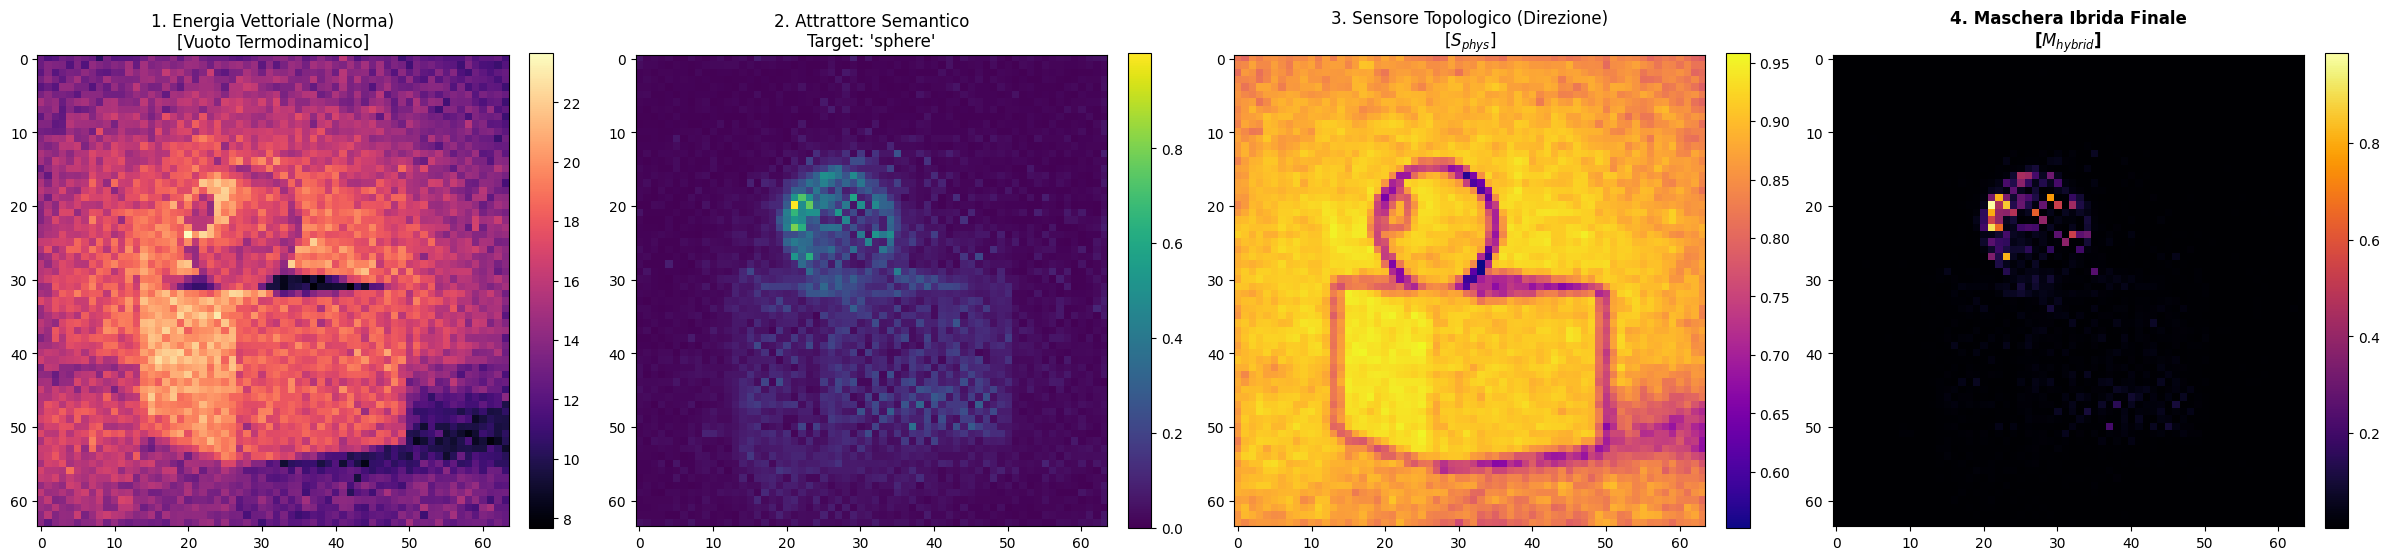

In [47]:

# ==========================================
# PIPELINE DI ESECUZIONE E PREPARAZIONE DATI
# ==========================================
def run_supervised_hybrid_pipeline(db_path: str, word_to_isolate: str, manual_tokens: list = None):
    decoder = SupervisedHybridDecoder(k=12.0, lambda_val=0.45)
    
    # 1. CARICAMENTO METADATI E DATI GREZZI
    with open(os.path.join(db_path, "metadata.json"), "r") as f:
        target_prompt = json.load(f)["prompt"]
    print(f"Prompt caricato: '{target_prompt}'")
    
    attn_data = torch.load(os.path.join(db_path, "attention_maps.pt"), map_location="cpu", weights_only=False)
    v_data = torch.load(os.path.join(db_path, "v0_velocity.pt"), map_location="cpu", weights_only=True)
    
    # 2. PULIZIA E RESHAPING (Unpatchify Robusto)
    # -- Attenzione: estraiamo il layer, togliamo il batch -> [Heads, 4096, Text_Seq]
    attn_tensor = attn_data['layer_10'].to(torch.float32).squeeze(0)
    
    # -- Velocità: togliamo il batch, ricostruiamo griglia e spostiamo i canali in testa -> [C, H, W]
    H = W = int(v_data.shape[1] ** 0.5)          # v_data ha shape [1, Seq_Len, C] (es. [1, 4096, C])
    v_t = v_data.to(torch.float32).squeeze(0).view(H, W, -1).permute(2, 0, 1)
        
    # 3. ESECUZIONE MATEMATICA
    M_hybrid, S_sem, S_phys = decoder(
        attn_tensor=attn_tensor, 
        v_t=v_t, 
        prompt=target_prompt, 
        target_word=word_to_isolate, 
        spatial_shape=(H,W),
        manual_tokens=manual_tokens
    )
    
    # --- VISUALIZZAZIONE ---
    plt.style.use('default') 
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))
    
    im0 = axs[0].imshow(torch.norm(v_t, dim=0).cpu().numpy(), cmap='magma')
    axs[0].set_title("1. Energia Vettoriale (Norma)\n[Vuoto Termodinamico]", fontsize=12)
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    im1 = axs[1].imshow(S_sem.cpu().numpy(), cmap='viridis')
    axs[1].set_title(f"2. Attrattore Semantico\nTarget: '{word_to_isolate}'", fontsize=12)
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    
    im2 = axs[2].imshow(S_phys.cpu().numpy(), cmap='plasma')
    axs[2].set_title("3. Sensore Topologico (Direzione)\n[$S_{phys}$]", fontsize=12)
    fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    
    im3 = axs[3].imshow(M_hybrid.cpu().numpy(), cmap='inferno')
    axs[3].set_title("4. Maschera Ibrida Finale\n[$M_{hybrid}$]", fontsize=12, fontweight='bold')
    fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    return M_hybrid

maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_red_cube",
    word_to_isolate="cube"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_blue_sphere",
    word_to_isolate="sphere"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_yellow_pyramid",
    word_to_isolate="pyramid"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_blue_cube_and_a_red_sphere",
    word_to_isolate="cube"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_blue_cube_and_a_red_sphere",
    word_to_isolate="sphere"
)

## 5.3 SvdCosineHybridDecoder: SVD per Consenso Multi-Testa

Anziché mediare naïvemente le 24 teste di attenzione, usiamo **SVD** per estrarre 
la componente a massima varianza — l'autovettore primario è il "consenso globale" 
delle teste, eliminando quelle rumorose.

Il sensore fisico passa dalla cosine similarity locale (§5.2) a quella **globale** 
(matrice di affinità completa, elevata al cubo per contrasto).

Codice integrato in `flowstitch.extraction.decoders.svd_cosine_hybrid`.

In [48]:
from flowstitch.extraction.decoders.svd_cosine_hybrid import SvdCosineHybridDecoder


Analisi per: 'a yellow pyramid' (Target: pyramid)


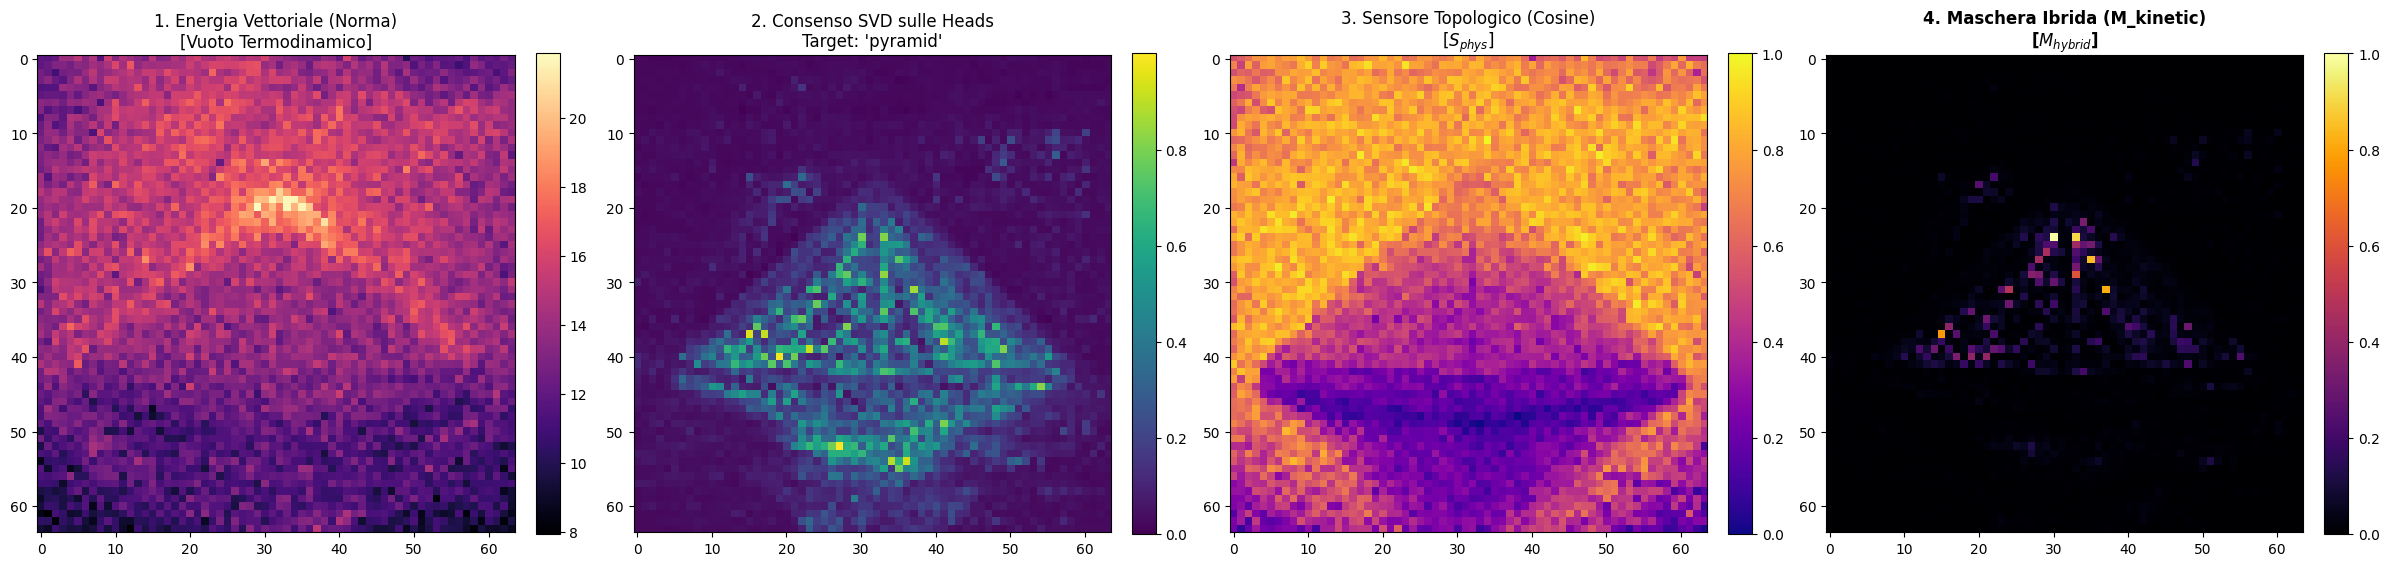


Analisi per: 'a blue sphere' (Target: sphere)


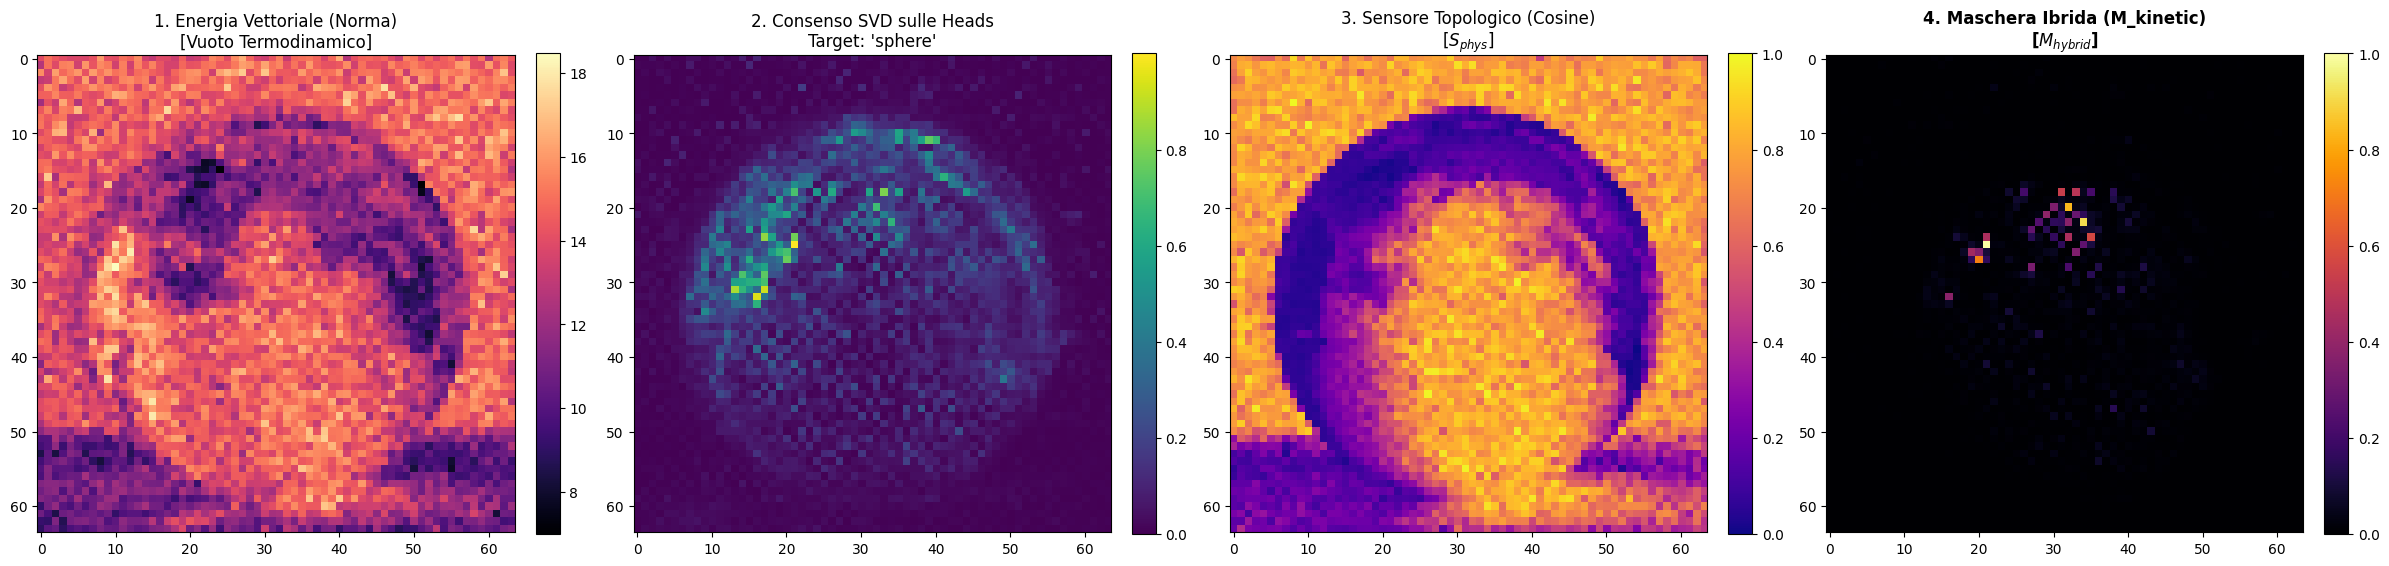


Analisi per: 'a red cube' (Target: cube)


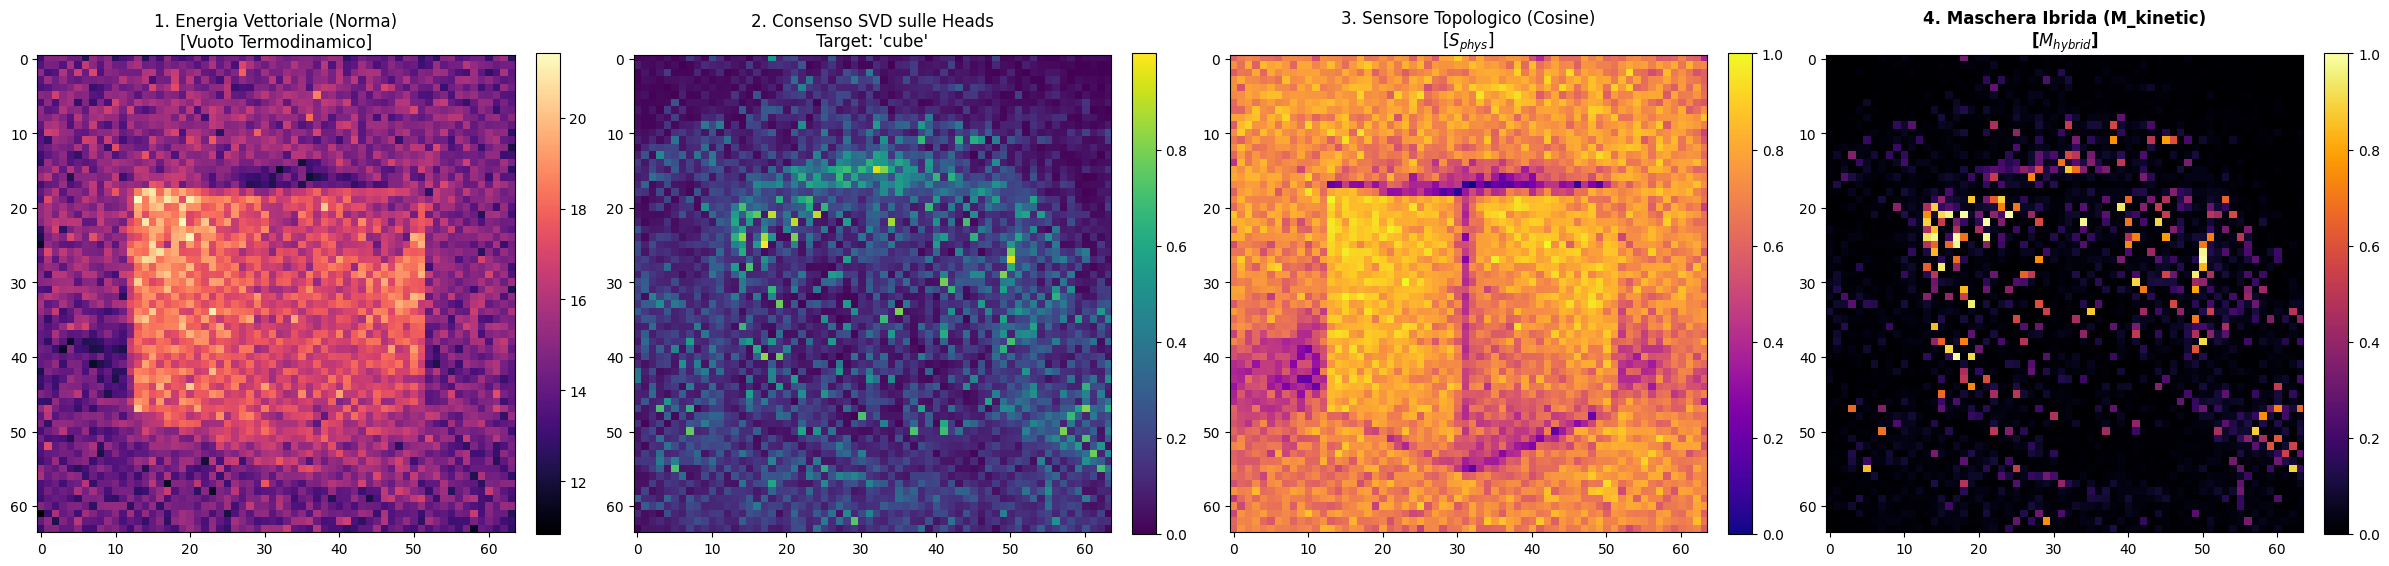


Analisi per: 'a blue cube and a red sphere' (Target: sphere)


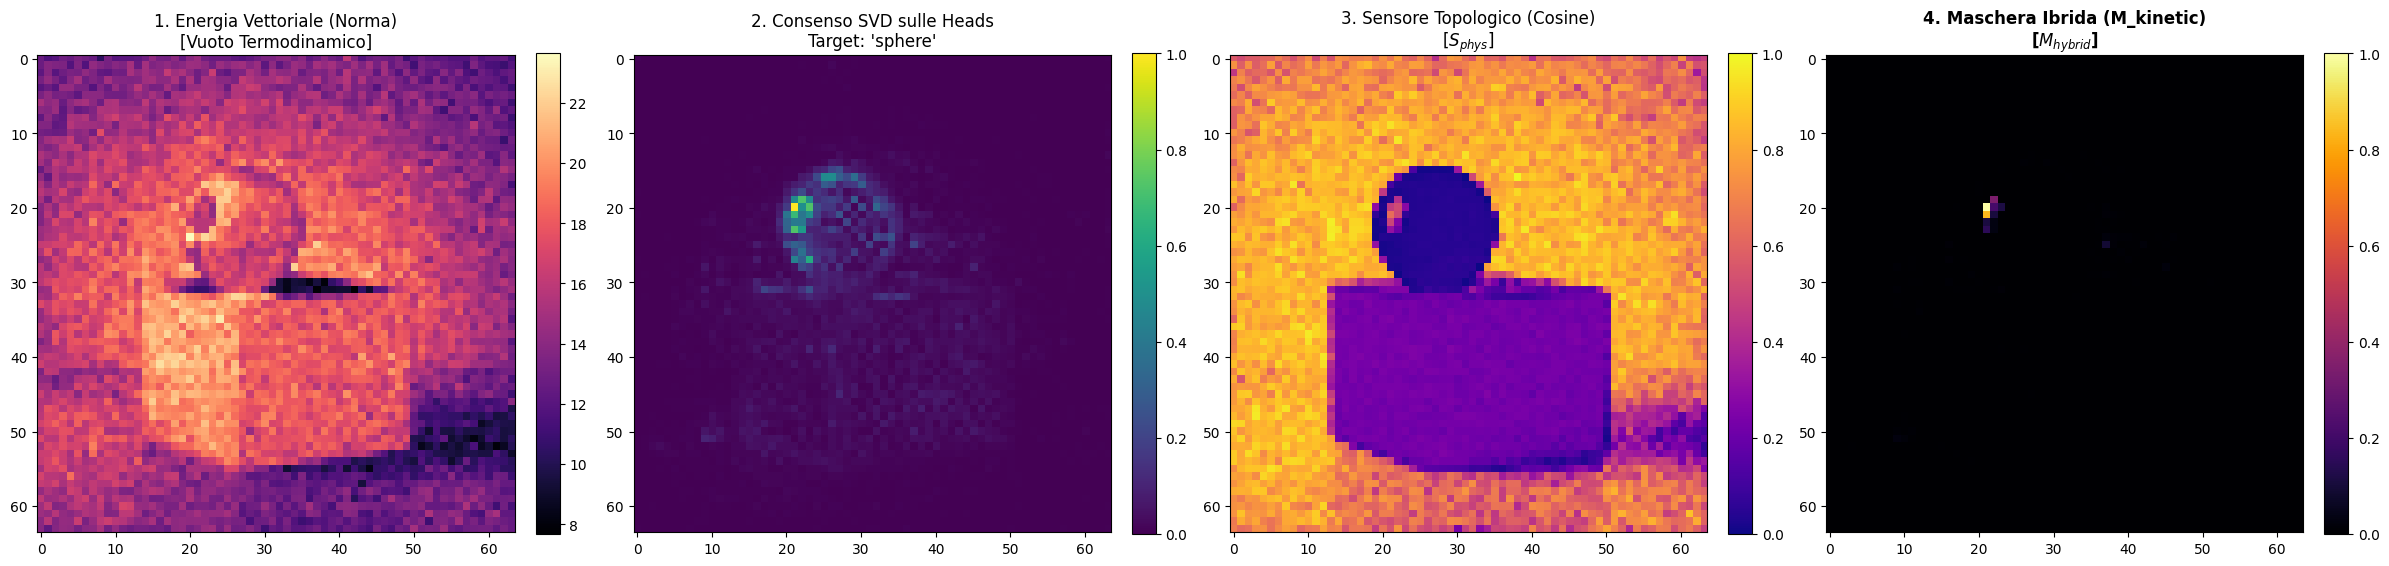

In [49]:


# ==========================================
# 2. FUNZIONE DI RUN ED ESPORTAZIONE
# ==========================================
def run_supervised_hybrid_pipeline(db_path: str, word_to_isolate: str):
    decoder = SvdCosineHybridDecoder(k=12.0, lambda_val=0.4) # lambda a 0.4 è un buon compromesso
    
    # 1. Caricamento Metadati
    with open(os.path.join(db_path, "metadata.json"), "r") as f:
        target_prompt = json.load(f)["prompt"]
    print(f"\nAnalisi per: '{target_prompt}' (Target: {word_to_isolate})")
    
    attn_data = torch.load(os.path.join(db_path, "attention_maps.pt"), map_location="cpu", weights_only=False)
    v_data = torch.load(os.path.join(db_path, "v0_velocity.pt"), map_location="cpu", weights_only=True)
    
    # 2. Unpatchify Robusto (Mantiene le Heads intatte!)
    attn_tensor = attn_data['layer_10'].to(torch.float32).squeeze(0) # [Heads, 4096, Seq]
    
    H = W = int(v_data.shape[1] ** 0.5)
    v_t = v_data.to(torch.float32).squeeze(0).view(H, W, -1).permute(2, 0, 1) # [C, H, W]
        
    # 3. Esecuzione del Decoder Ibrido
    M_hybrid, S_sem, S_phys = decoder(
        attn_tensor=attn_tensor, 
        v_t=v_t, 
        prompt=target_prompt, 
        target_word=word_to_isolate, 
        spatial_shape=(H,W)
    )
    
    # 4. Generazione delle Maschere Separate per la Generazione FLUX
    M_kinetic = M_hybrid.clone() # Maschera Tagliente per l'ODE Loop
    
    # Maschera Solida per l'Attenzione (Garantita dalla purezza della SVD sulle Heads)
    M_semantic = torch.sigmoid(20.0 * (S_sem - 0.2))
    M_semantic = (M_semantic - M_semantic.min()) / (M_semantic.max() - M_semantic.min() + 1e-8)
    
    # --- VISUALIZZAZIONE ---
    plt.style.use('default') 
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))
    
    im0 = axs[0].imshow(torch.norm(v_t, dim=0).cpu().numpy(), cmap='magma')
    axs[0].set_title("1. Energia Vettoriale (Norma)\n[Vuoto Termodinamico]", fontsize=12)
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    im1 = axs[1].imshow(S_sem.cpu().numpy(), cmap='viridis')
    axs[1].set_title(f"2. Consenso SVD sulle Heads\nTarget: '{word_to_isolate}'", fontsize=12)
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    
    im2 = axs[2].imshow(S_phys.cpu().numpy(), cmap='plasma')
    axs[2].set_title("3. Sensore Topologico (Cosine)\n[$S_{phys}$]", fontsize=12)
    fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    
    im3 = axs[3].imshow(M_hybrid.cpu().numpy(), cmap='inferno')
    axs[3].set_title("4. Maschera Ibrida (M_kinetic)\n[$M_{hybrid}$]", fontsize=12, fontweight='bold')
    fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Ritorna i tensori pronti per essere salvati/iniettati nel FluxPipeline
    return M_kinetic, M_semantic

# --- ESECUZIONE TEST ---
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_yellow_pyramid", word_to_isolate="pyramid")
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_blue_sphere", word_to_isolate="sphere")
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_red_cube", word_to_isolate="cube")
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_blue_cube_and_a_red_sphere", word_to_isolate="sphere")

## 5.4 GraphDiffusionHybridDecoder: Random Walk di Markov

Abbandonando completamente le soglie statistiche, costruiamo un **grafo di Markov** 
sulla matrice di cosine similarity del campo $v_0$. Un random walk inizializzato 
sul seed semantico diffonde la probabilità ai pixel strutturalmente simili.

Il random walk **riempie naturalmente il Vuoto Termodinamico**: la probabilità 
diffonde dal bordo (alta energia) al centro (bassa energia) attraverso i "tubi" 
di alta cosine similarity.

**Limitazione**: il seed iniziale (media delle heads) è rumoroso.

Codice integrato in `flowstitch.extraction.decoders.graph_diffusion`.

In [52]:
from flowstitch.extraction.decoders.graph_diffusion import GraphDiffusionHybridDecoder

Prompt caricato: 'a red cube'


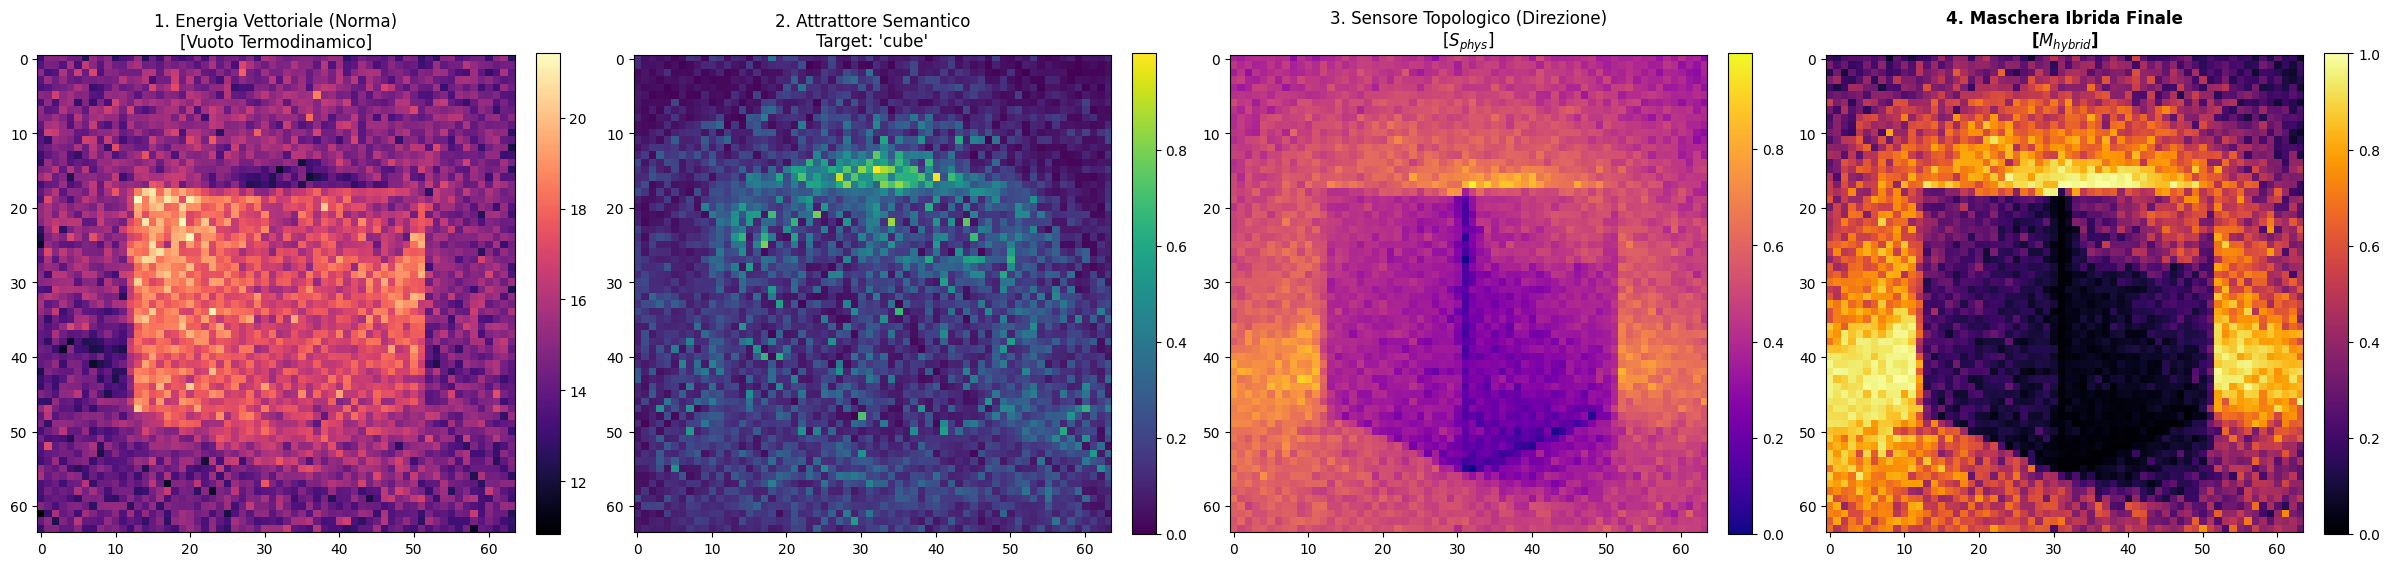

Prompt caricato: 'a blue sphere'


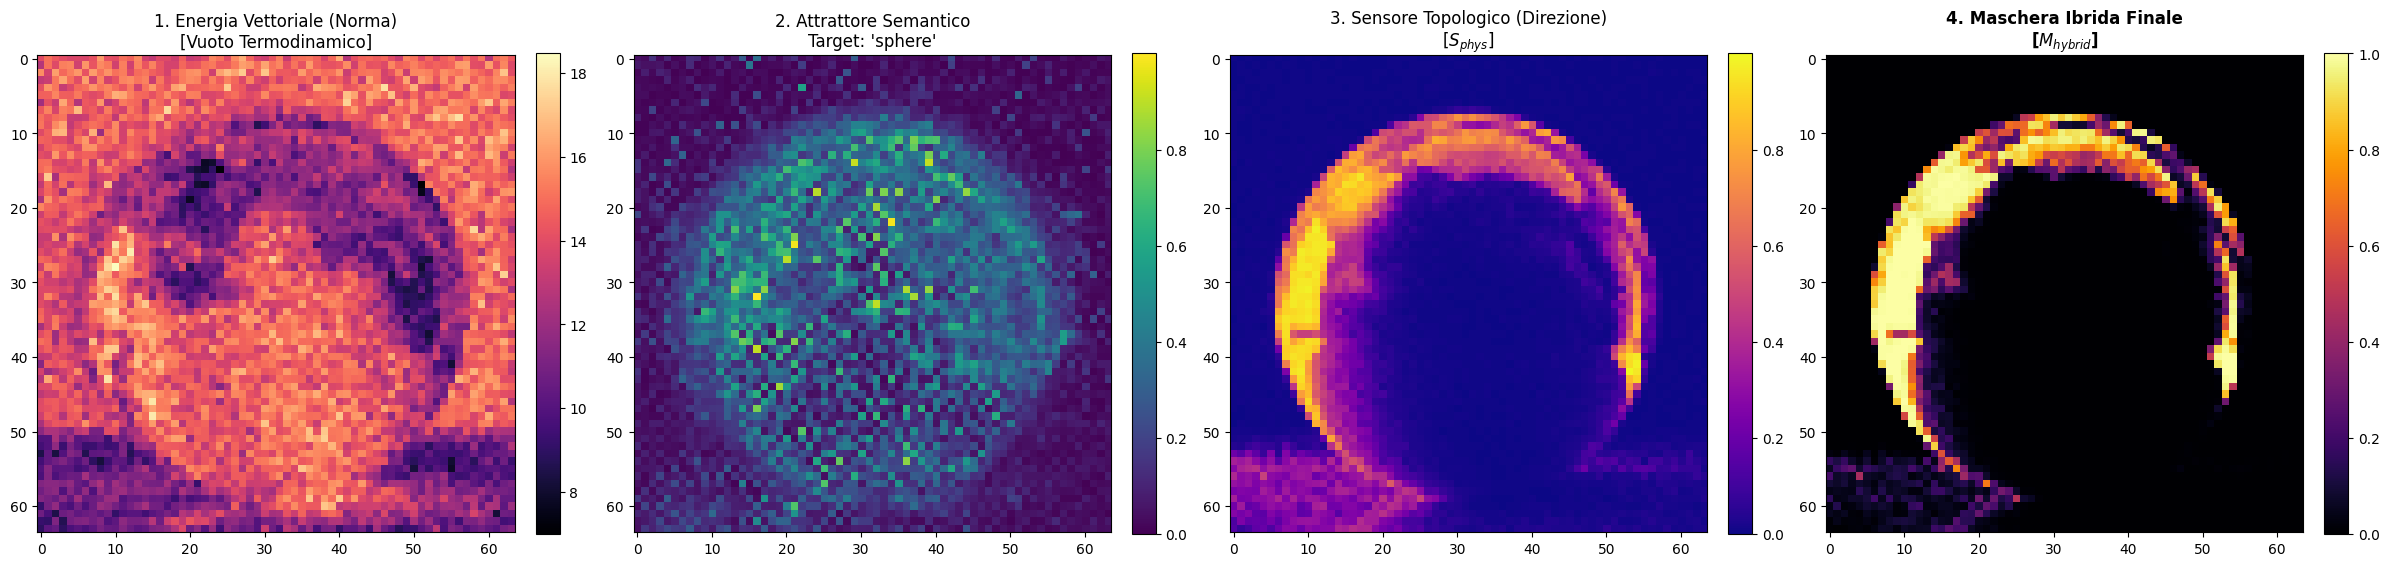

Prompt caricato: 'a yellow pyramid'


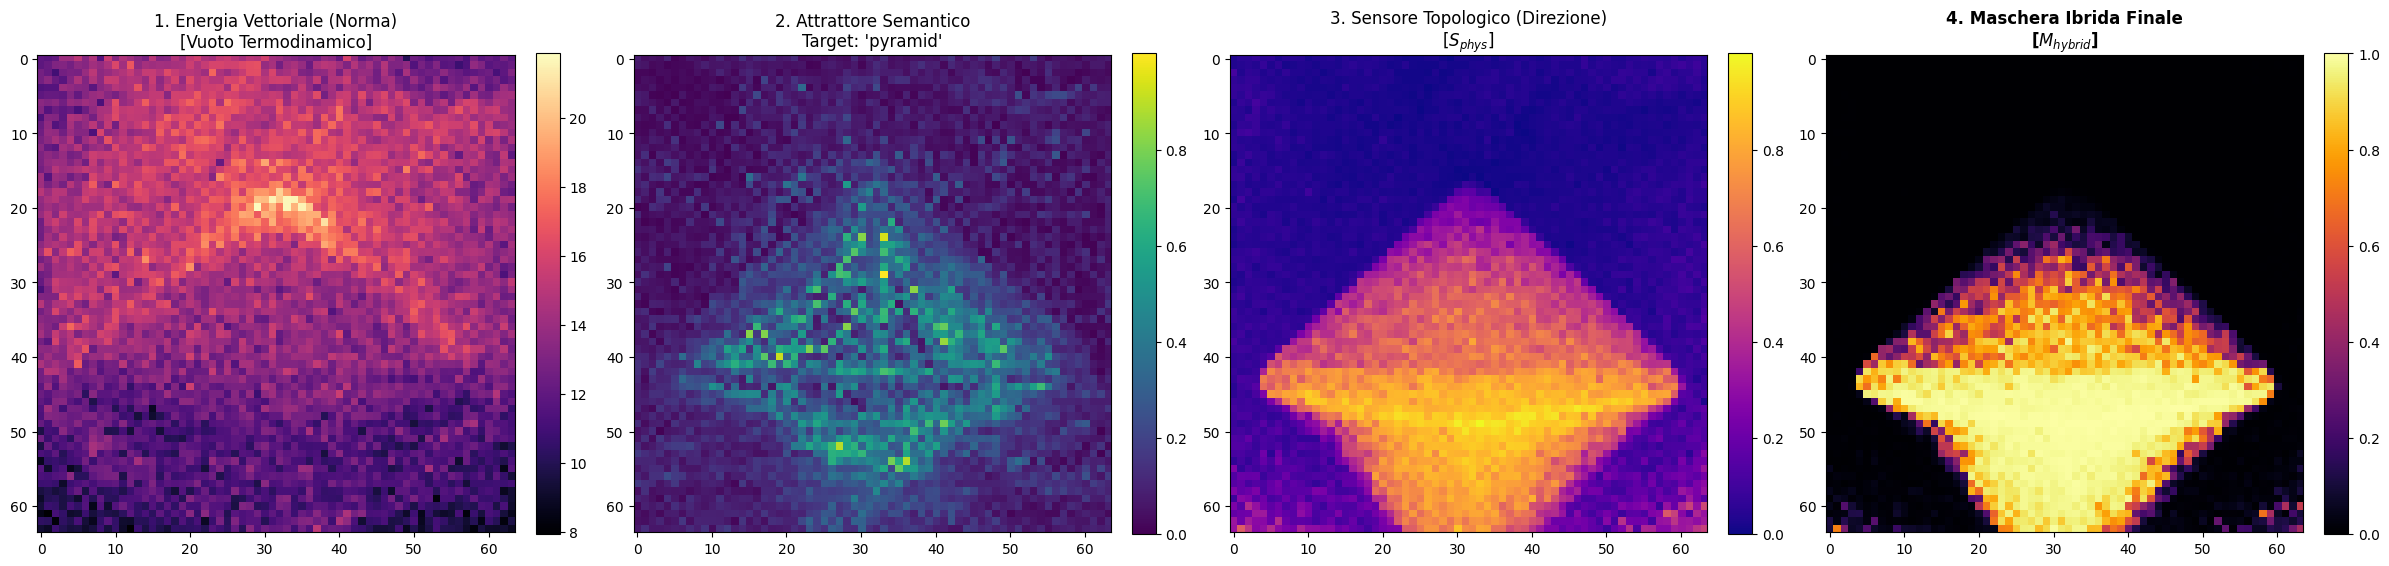

Prompt caricato: 'a blue cube and a red sphere'


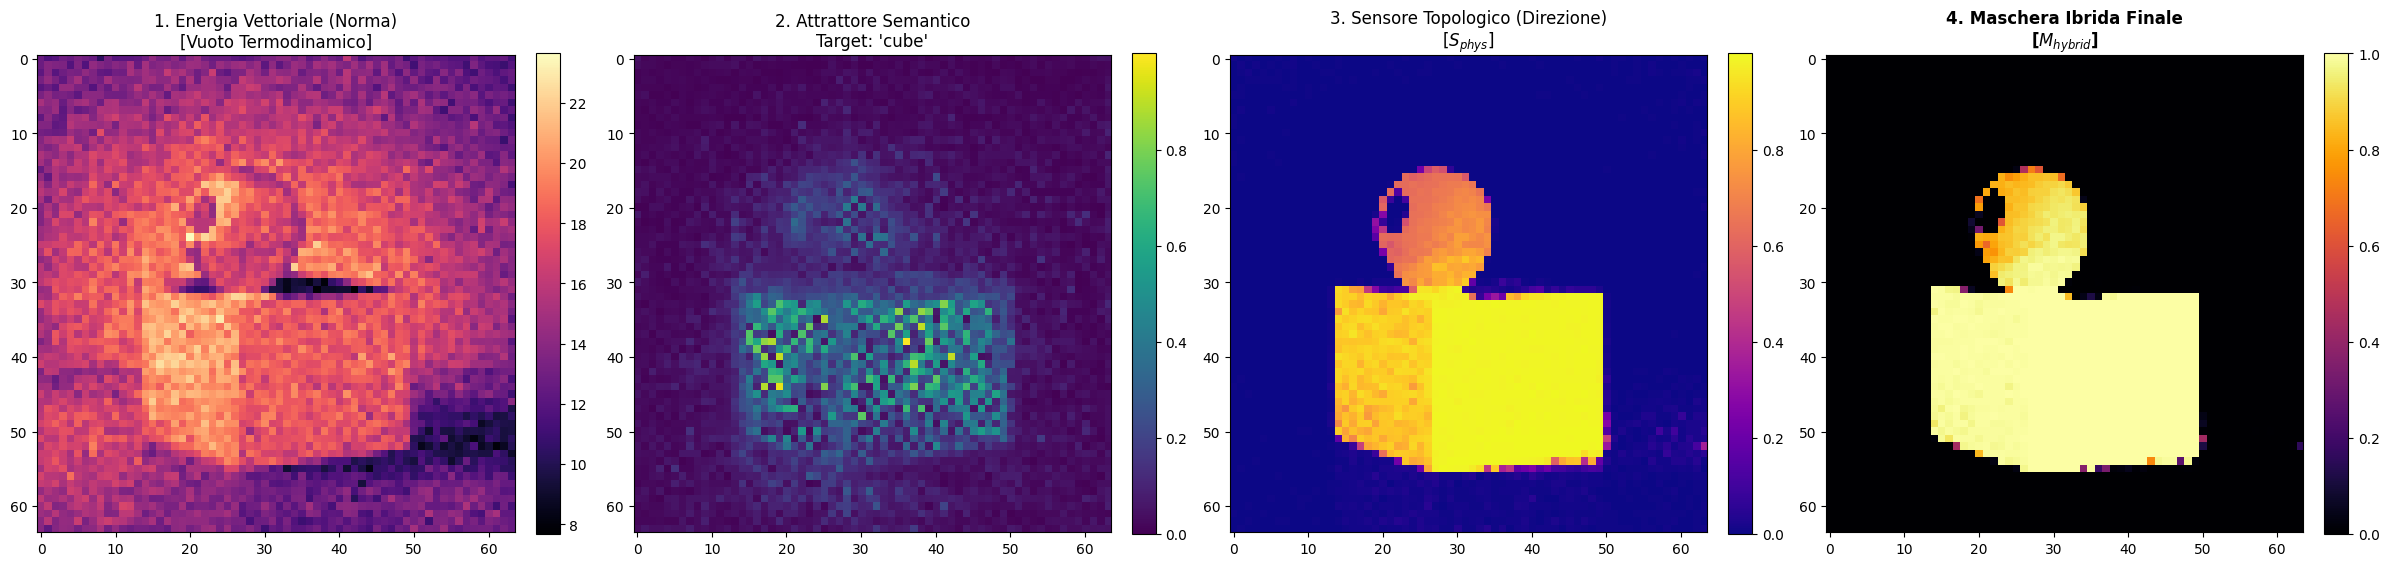

Prompt caricato: 'a blue cube and a red sphere'


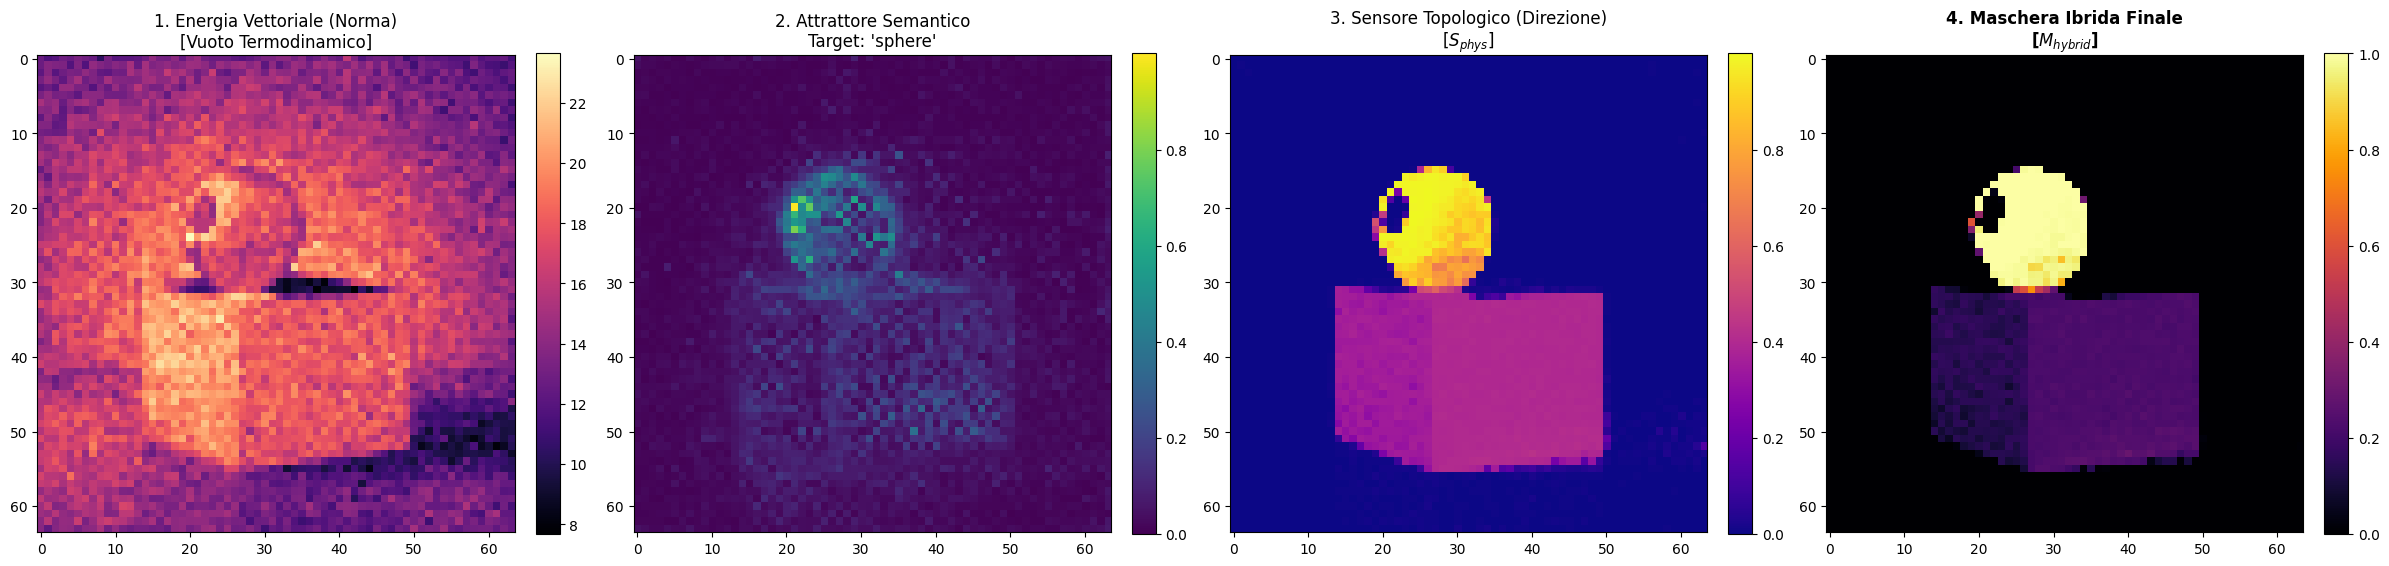

In [53]:

# ==========================================
# PIPELINE DI ESECUZIONE E PREPARAZIONE DATI
# ==========================================
def run_supervised_hybrid_pipeline(db_path: str, word_to_isolate: str, manual_tokens: list = None):
    decoder = GraphDiffusionHybridDecoder()
    
    # 1. CARICAMENTO METADATI E DATI GREZZI
    with open(os.path.join(db_path, "metadata.json"), "r") as f:
        target_prompt = json.load(f)["prompt"]
    print(f"Prompt caricato: '{target_prompt}'")
    
    attn_data = torch.load(os.path.join(db_path, "attention_maps.pt"), map_location="cpu", weights_only=False)
    v_data = torch.load(os.path.join(db_path, "v0_velocity.pt"), map_location="cpu", weights_only=True)
    
    # 2. PULIZIA E RESHAPING (Unpatchify Robusto)
    # -- Attenzione: estraiamo il layer, togliamo il batch -> [Heads, 4096, Text_Seq]
    attn_tensor = attn_data['layer_10'].to(torch.float32).squeeze(0)
    
    # -- Velocità: togliamo il batch, ricostruiamo griglia e spostiamo i canali in testa -> [C, H, W]
    H = W = int(v_data.shape[1] ** 0.5)          # v_data ha shape [1, Seq_Len, C] (es. [1, 4096, C])
    v_t = v_data.to(torch.float32).squeeze(0).view(H, W, -1).permute(2, 0, 1)
        
    # 3. ESECUZIONE MATEMATICA
    M_hybrid, S_sem, S_phys = decoder(
        attn_tensor=attn_tensor, 
        v_t=v_t, 
        prompt=target_prompt, 
        target_word=word_to_isolate, 
        spatial_shape=(H,W)
    )
    
    # --- VISUALIZZAZIONE ---
    plt.style.use('default') 
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))
    
    im0 = axs[0].imshow(torch.norm(v_t, dim=0).cpu().numpy(), cmap='magma')
    axs[0].set_title("1. Energia Vettoriale (Norma)\n[Vuoto Termodinamico]", fontsize=12)
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    im1 = axs[1].imshow(S_sem.cpu().numpy(), cmap='viridis')
    axs[1].set_title(f"2. Attrattore Semantico\nTarget: '{word_to_isolate}'", fontsize=12)
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    
    im2 = axs[2].imshow(S_phys.cpu().numpy(), cmap='plasma')
    axs[2].set_title("3. Sensore Topologico (Direzione)\n[$S_{phys}$]", fontsize=12)
    fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    
    im3 = axs[3].imshow(M_hybrid.cpu().numpy(), cmap='inferno')
    axs[3].set_title("4. Maschera Ibrida Finale\n[$M_{hybrid}$]", fontsize=12, fontweight='bold')
    fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    return M_hybrid

maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_red_cube",
    word_to_isolate="cube"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_blue_sphere",
    word_to_isolate="sphere"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_yellow_pyramid",
    word_to_isolate="pyramid"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_blue_cube_and_a_red_sphere",
    word_to_isolate="cube"
)
maschera = run_supervised_hybrid_pipeline(
    db_path="../data/dataset_v1/a_blue_cube_and_a_red_sphere",
    word_to_isolate="sphere"
)

## 5.5 SvdSeededGraphDiffusionDecoder: Il Decoder Definitivo

Combiniamo il meglio dei decoder precedenti:
- **SVD** (da §5.3) per il seed semantico purificato — "l'inchiostro purissimo"
- **Graph Diffusion** (da §5.5) per la propagazione strutturale — "i tubi"

Questo decoder risolve simultaneamente:
1. Il Vuoto Termodinamico (la diffusione riempie il centro)
2. Il rumore semantico (SVD purifica il segnale)

Codice integrato in `flowstitch.extraction.decoders.svd_graph_diffusion`.

In [54]:
from flowstitch.extraction.decoders.svd_graph_diffusion import SvdSeededGraphDiffusionDecoder


Analisi per: 'a red cube' (Target: cube)


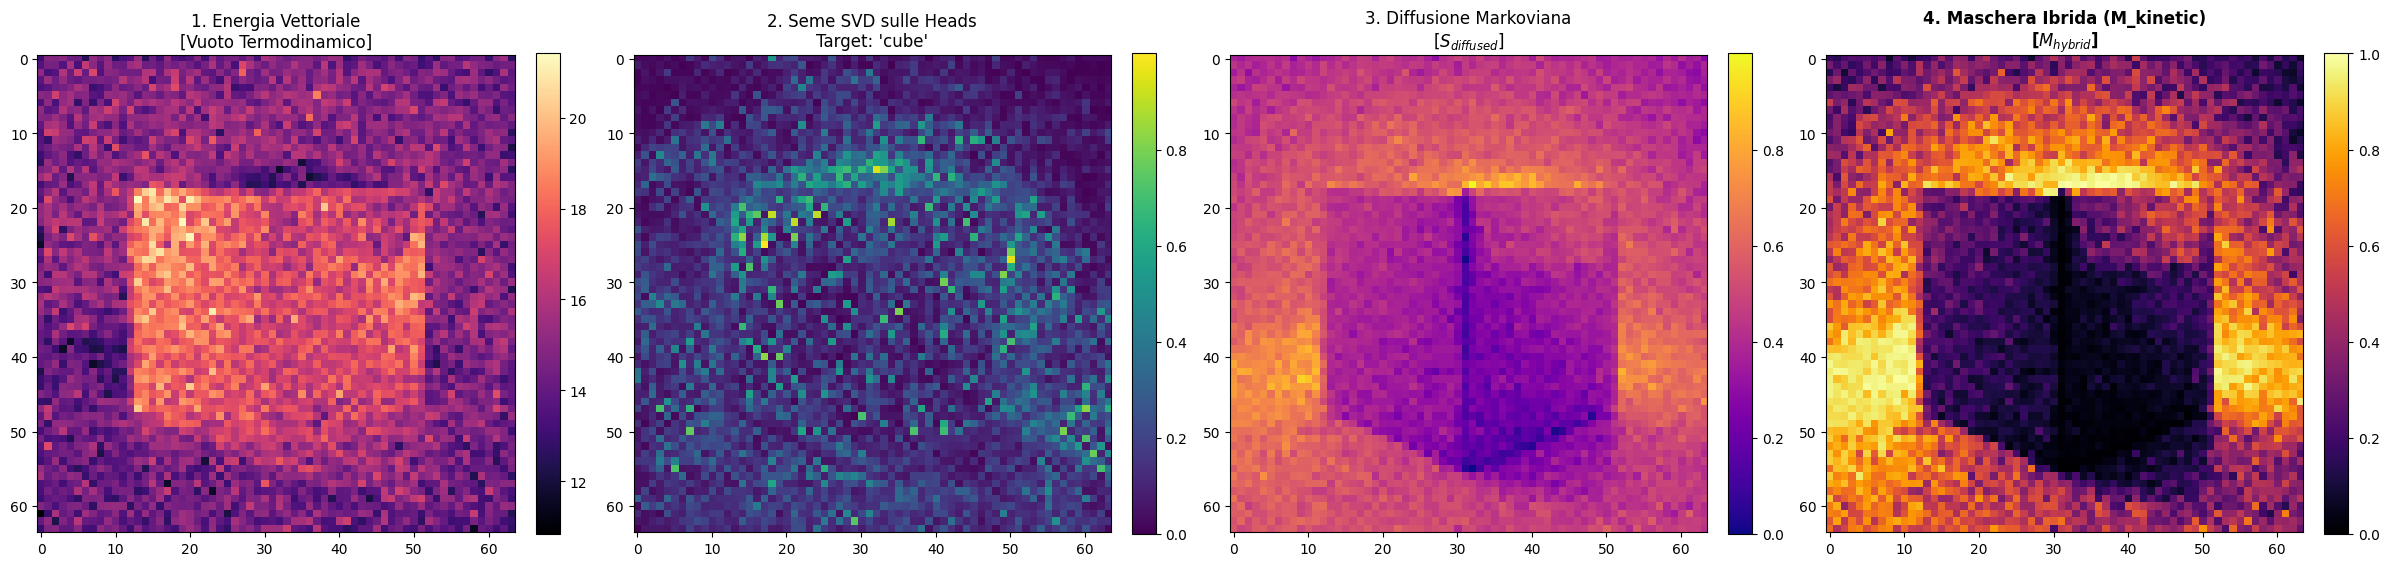


Analisi per: 'a blue sphere' (Target: sphere)


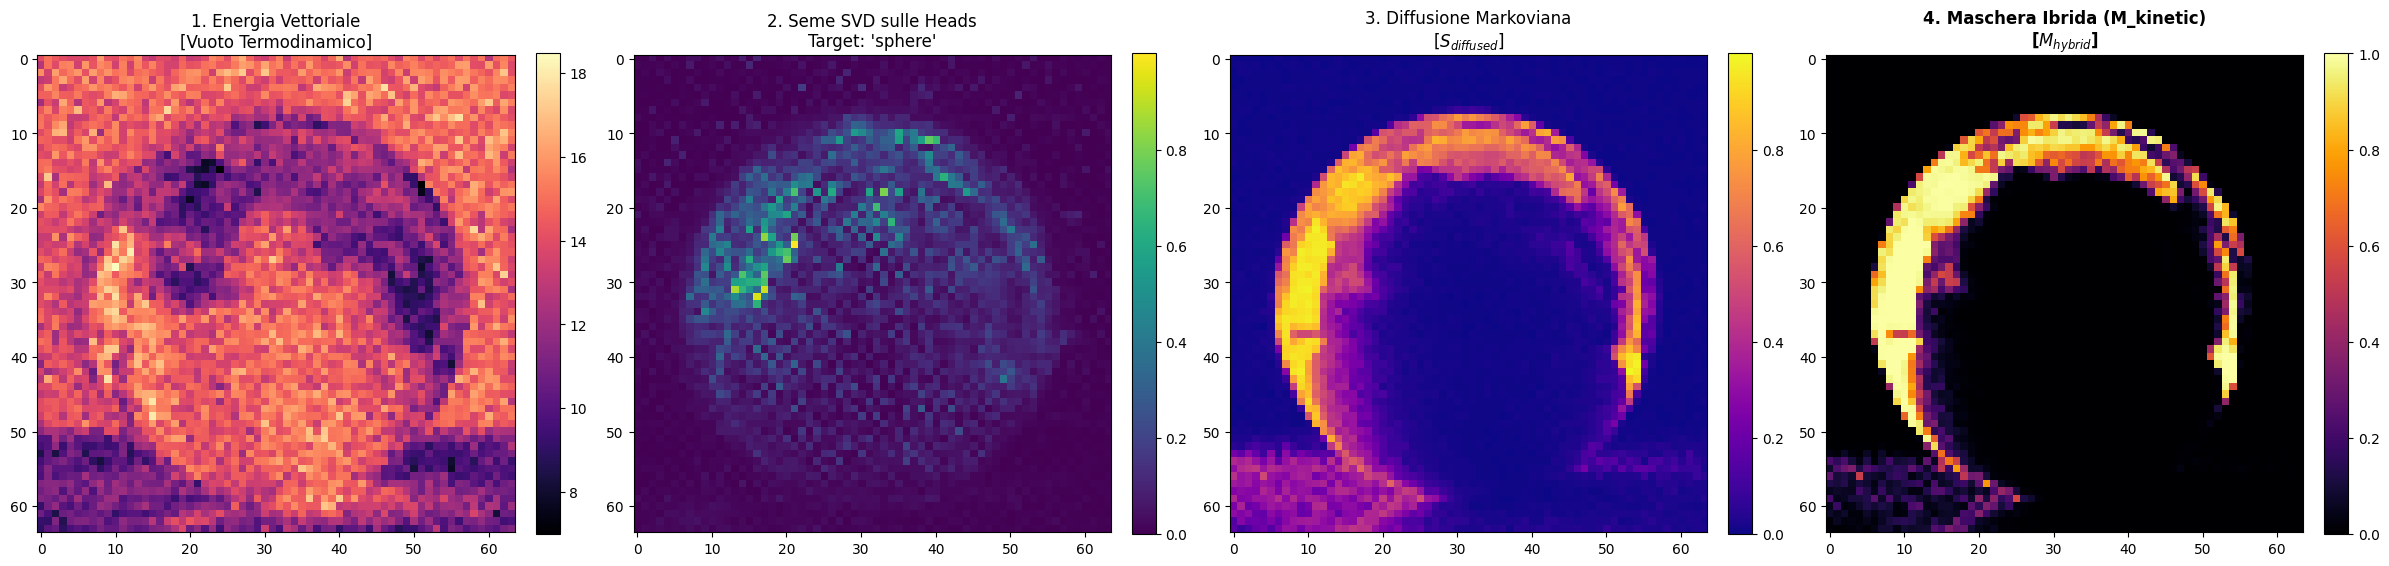


Analisi per: 'a yellow pyramid' (Target: pyramid)


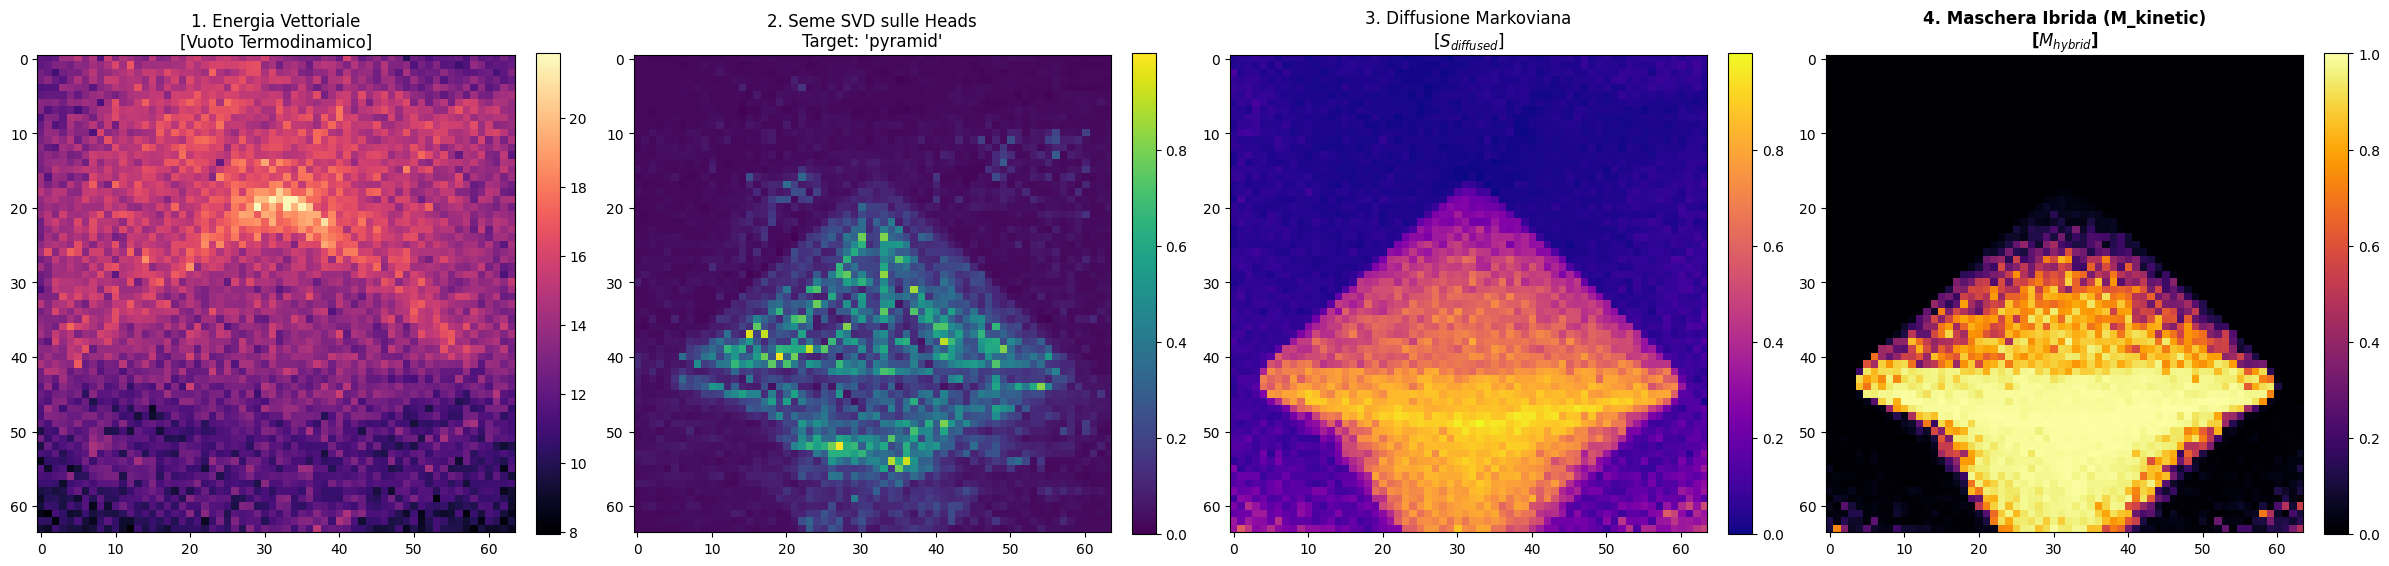


Analisi per: 'a blue cube and a red sphere' (Target: cube)


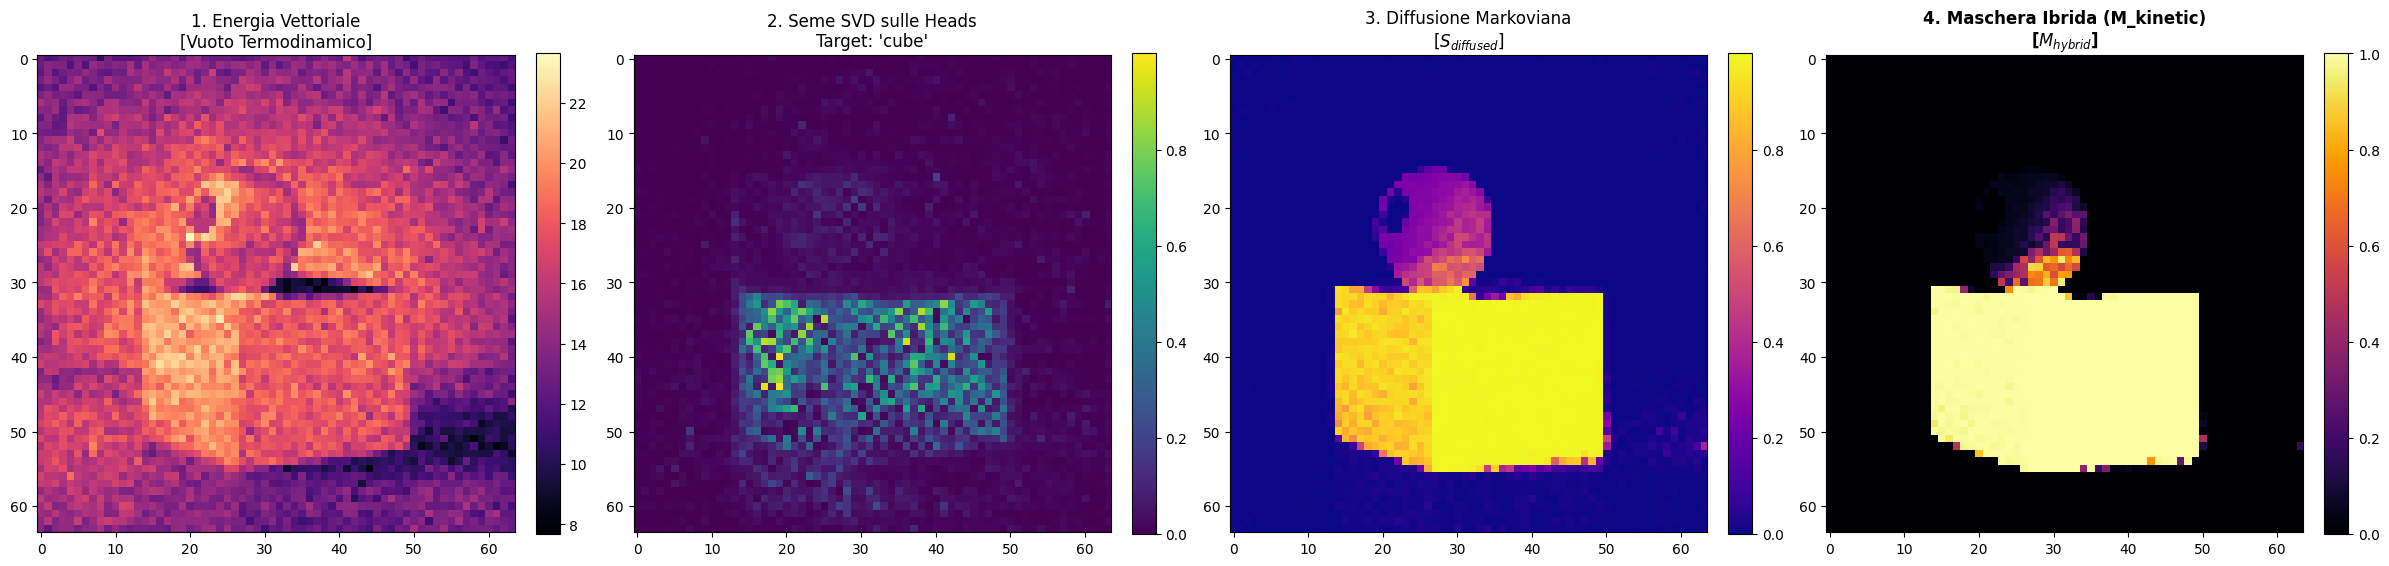


Analisi per: 'a blue cube and a red sphere' (Target: sphere)


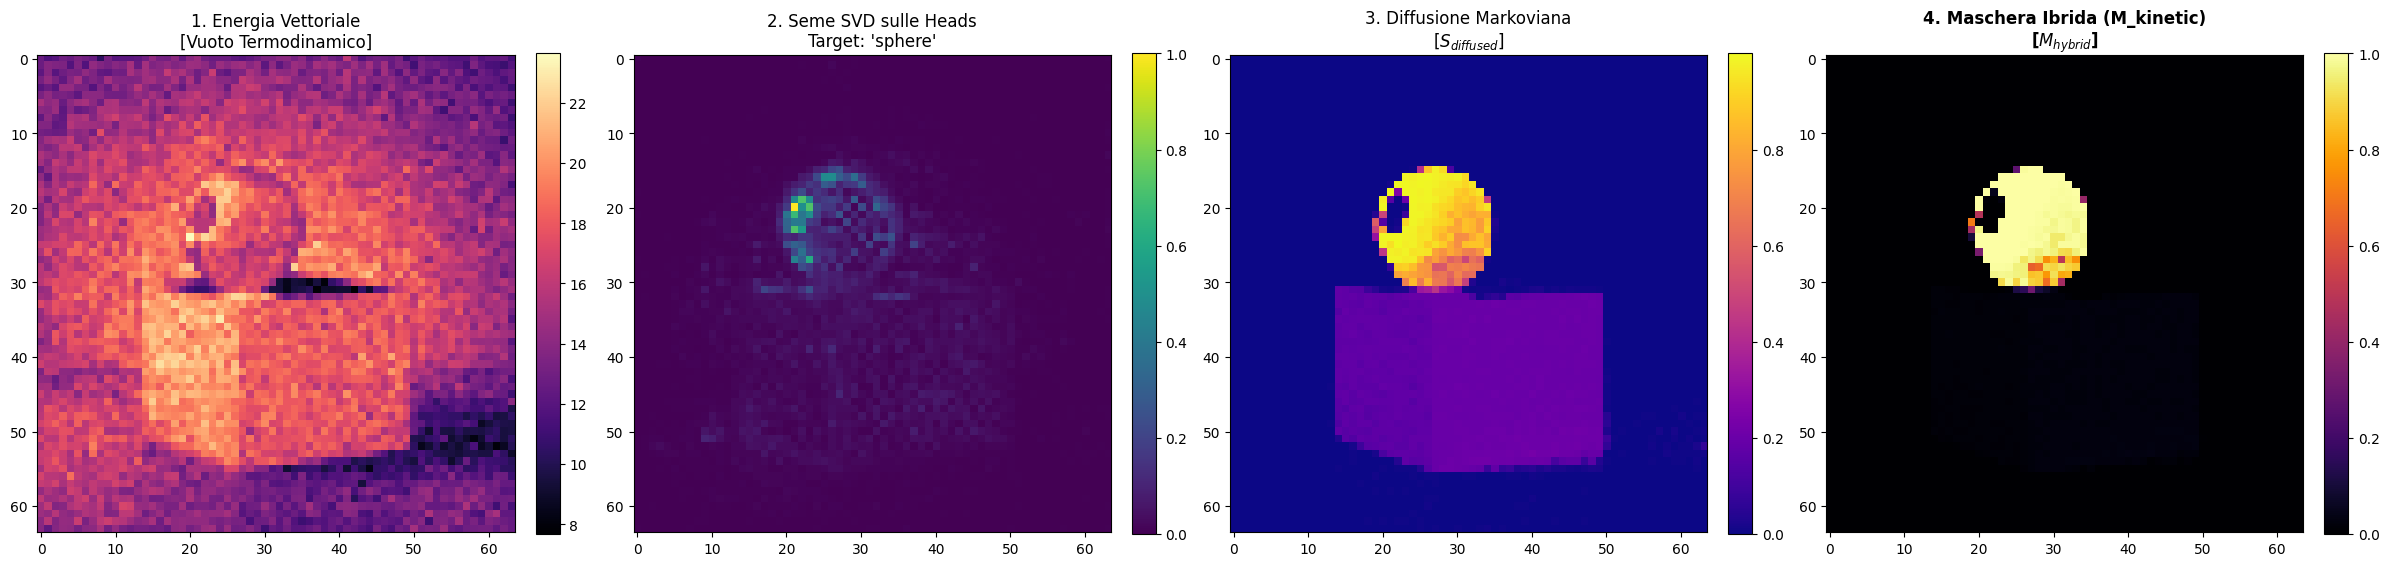

In [ ]:
# ==========================================
# PIPELINE DI ESECUZIONE E PREPARAZIONE DATI
# ==========================================
def run_supervised_hybrid_pipeline(db_path: str, word_to_isolate: str):
    # Inizializziamo il Decoder Definitivo (SVD + Graph Diffusion)
    decoder = SvdSeededGraphDiffusionDecoder(k=12.0, diffusion_steps=3)
    
    # 1. CARICAMENTO METADATI E DATI GREZZI
    with open(os.path.join(db_path, "metadata.json"), "r") as f:
        target_prompt = json.load(f)["prompt"]
    print(f"\nAnalisi per: '{target_prompt}' (Target: {word_to_isolate})")
    
    attn_data = torch.load(os.path.join(db_path, "attention_maps.pt"), map_location="cpu", weights_only=False)
    v_data = torch.load(os.path.join(db_path, "v0_velocity.pt"), map_location="cpu", weights_only=True)
    
    # 2. PULIZIA E RESHAPING 
    # Manteniamo le Heads intatte per la SVD! -> [Heads, 4096, Text_Seq]
    attn_tensor = attn_data['layer_10'].to(torch.float32).squeeze(0)
    
    H = W = int(v_data.shape[1] ** 0.5)
    v_t = v_data.to(torch.float32).squeeze(0).view(H, W, -1).permute(2, 0, 1) # [C, H, W]
        
    # 3. ESECUZIONE MATEMATICA (La Fusione)
    M_hybrid, S_seed, S_diffused = decoder(
        attn_tensor=attn_tensor, 
        v_t=v_t, 
        prompt=target_prompt, 
        target_word=word_to_isolate, 
        spatial_shape=(H,W)
    )
    
    # 4. ESTRAZIONE DELLE MASCHERE DIFFERENZIATE
    # -> Per l'ODE Loop (Bisturi cinematico, preserva il buco termodinamico se presente)
    M_kinetic = M_hybrid.clone() 
    
    # -> Per l'Attenzione (Scudo semantico: prendiamo il liquido diffuso e applichiamo 
    # una sigmoide molto dura e anticipata per tappare ogni possibile buco interno)
    M_semantic = torch.sigmoid(20.0 * (S_diffused - 0.2))
    M_semantic = (M_semantic - M_semantic.min()) / (M_semantic.max() - M_semantic.min() + 1e-8)
    
    # --- VISUALIZZAZIONE ---
    plt.style.use('default') 
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))
    
    im0 = axs[0].imshow(torch.norm(v_t, dim=0).cpu().numpy(), cmap='magma')
    axs[0].set_title("1. Energia Vettoriale\n[Vuoto Termodinamico]", fontsize=12)
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    im1 = axs[1].imshow(S_seed.cpu().numpy(), cmap='viridis')
    axs[1].set_title(f"2. Seme SVD sulle Heads\nTarget: '{word_to_isolate}'", fontsize=12)
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    
    im2 = axs[2].imshow(S_diffused.cpu().numpy(), cmap='plasma')
    axs[2].set_title("3. Diffusione Markoviana\n[$S_{diffused}$]", fontsize=12)
    fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    
    im3 = axs[3].imshow(M_hybrid.cpu().numpy(), cmap='inferno')
    axs[3].set_title("4. Maschera Ibrida (M_kinetic)\n[$M_{hybrid}$]", fontsize=12, fontweight='bold')
    fig.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    return M_kinetic, M_semantic

# ==========================================
# ESECUZIONE DEI TEST
# ==========================================
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_red_cube", word_to_isolate="cube")
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_blue_sphere", word_to_isolate="sphere")
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_yellow_pyramid", word_to_isolate="pyramid")
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_blue_cube_and_a_red_sphere", word_to_isolate="cube")
m_kin, m_sem = run_supervised_hybrid_pipeline(db_path="../data/dataset_v1/a_blue_cube_and_a_red_sphere", word_to_isolate="sphere")

## 5.6 Conclusioni e Confronto

| Decoder | Approccio | Vuoto Termodinamico | Rumore Semantico |
|---------|-----------|--------------------|--------------------|
| Chebyshev (§5.1) | μ+kσ threshold | ❌ Maschera a ciambella | ✅ Filtrato |
| SupervisedHybrid (§5.2) | Cosine locale + sigmoid | ⚠️ Parziale | ⚠️ Dipende da λ |
| SvdCosineHybrid (§5.3) | SVD heads + cosine globale | ⚠️ Parziale | ✅ SVD purifica |
| SpectralHybrid (§5.4) | Fiedler vector | ✅ Risolto | ✅ Bussola semantica |
| GraphDiffusion (§5.5) | Random walk Markov | ✅ Risolto | ❌ Seed rumoroso |
| **SvdSeeded+Diffusion (§5.6)** | **SVD + Markov** | **✅ Risolto** | **✅ Risolto** |

Il **SvdSeededGraphDiffusionDecoder** emerge come vincitore.

Nella prossima fase (Capitolo 6), introdurremo il Vettore di Fiedler con **decimazione bilineare** 
come alternativa più elegante e computazionalmente efficiente, insieme alla Topological Data Analysis 
(TDA) per la validazione formale.

---

## Collegamento al Codice: `flowstitch.extraction.decoders`

Tutti e 5 i decoder sperimentati in questo capitolo sono stati integrati nel pacchetto 
`flowstitch/extraction/decoders/`:

```python
from flowstitch.extraction.decoders import (
    SupervisedHybridDecoder,           # §5.2 — cosine similarity locale
    SvdCosineHybridDecoder,            # §5.3 — SVD multi-testa + cosine globale
    SupervisedSpectralHybridDecoder,   # §5.4 — Fiedler a risoluzione piena
    GraphDiffusionHybridDecoder,       # §5.5 — random walk di Markov
    SvdSeededGraphDiffusionDecoder,    # §5.6 — SVD + diffusione (vincitore)
)
```

### Interfaccia Comune

Ogni decoder accetta:
- `attn_tensor`: tensore di cross-attention `[Heads, H*W, Text_Seq]`
- `v_t`: campo di velocità `[C, H, W]`
- `token_indices`: indici dei token target
- `spatial_shape`: tupla `(H, W)` della griglia spaziale

E restituisce `(M_hybrid, S_signal, S_topology)`.

### Nota sulla Tokenizzazione

Nei notebook originali, ogni decoder conteneva la propria copia di `_find_token_indices()`.
Nella versione modulare, la tokenizzazione è delegata a `flowstitch.core.tokenizer_utils.find_token_indices()`,
e i decoder ricevono direttamente gli indici.


## Conclusione del Capitolo 5: Il Caleidoscopio dei Decoder

Abbiamo dimostrato che per calcolare una maschera di estrazione fisica perfetta (Zero-Shot Segmentation) a partire dal campo vettoriale, le euristiche scalari come Chebyshev falliscono a causa del **Vuoto Termodinamico**. Per riempire questo vuoto, siamo stati costretti ad architettare decodificatori basati su **Random Walk di Markov** e **Decomposizione a Valori Singolari (SVD)**.

Questo percorso di ricerca si è rivelato computazionalmente pesante, ma fondamentale per comprendere la geometria dello spazio latente. Nel prossimo capitolo (**Capitolo 6**), porteremo la Segmentazione Zero-Shot (Strada A) alla sua forma analitica definitiva tramite lo **Spectral Matting e la TDA**. Ma, soprattutto, avremo un'epifania: scopriremo che per l'obiettivo finale del Latent Stitching, il Vuoto Termodinamico è sempre stato un **falso problema**.